Exploration Data Analysis (EDA)
-

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import drive

# Data AB

## Load Data

In [ ]:
drive.mount('/content/drive')
zip_path = "/content/drive/Shared drives/Gestió de Projectes/Projecte/data/consum_anomalies_facturacio_complet_anonymized.zip"
extract_folder = "/content/drive/Shared drives/Gestió de Projectes/Projecte/data/Consum anomalies facturacio complet_anonymized"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

parquet_files = [f for f in os.listdir(extract_folder) if f.endswith('.parquet')]
if len(parquet_files) == 0:
    raise FileNotFoundError("No .parquet file found in the ZIP!")
parquet_path = os.path.join(extract_folder, parquet_files[0])

df_ab = pd.read_parquet(parquet_path)
print(f"Data loaded from {parquet_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data loaded from /content/drive/Shared drives/Gestió de Projectes/Projecte/data/Consum anomalies facturacio complet_anonymized/Consum anomalies facturacio complet_anonymized.parquet


## General Info

In [ ]:
print("First five rows:\n")
df_ab.head()

First five rows:



,POLISSA_SUBM,CODI_ANOMALIA,START_DATE,END_DATE,US_AIGUA_SUBM,SECCIO_CENSAL,NUMEROSERIECONTADOR,CONSUMO_REAL,FECHA_HORA
0,TZSHLTAPLXX4OYI3,163840,2024-07-08,2024-09-05,DOMÈSTIC,0805601006,P22FA037836K,NaN,2024-01-01
1,FJ2I5K246X6SG3T4,163840,2023-01-26,2023-03-27,DOMÈSTIC,0805602004,P21VA155772I,NaN,2024-01-01
2,MPIXKKMZKJXANKKB,163840,2024-05-07,2024-07-05,DOMÈSTIC,0801507024,I20LA206734D,NaN,2024-01-01
3,LV6FI7TE7BX7NKKE,163840,2023-01-11,2023-03-13,DOMÈSTIC,0820002005,I19LA121835K,NaN,2024-01-01
4,RSSOFEQOC53RL6OD,2,2023-01-16,2023-03-16,DOMÈSTIC,0801906059,P15VA076725J,NaN,2024-01-01


In [ ]:
print("\nData types:\n", df_ab.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21195970 entries, 0 to 21195969
Data columns (total 9 columns):
 #   Column               Dtype         
---  ------               -----         
 0   POLISSA_SUBM         object        
 1   CODI_ANOMALIA        int64         
 2   START_DATE           datetime64[ns]
 3   END_DATE             datetime64[ns]
 4   US_AIGUA_SUBM        object        
 5   SECCIO_CENSAL        object        
 6   NUMEROSERIECONTADOR  object        
 7   CONSUMO_REAL         float64       
 8   FECHA_HORA           datetime64[us]
dtypes: datetime64[ns](2), datetime64[us](1), float64(1), int64(1), object(4)
memory usage: 1.4+ GB

Data types:
 None


In [ ]:
print("Null value counts:\n", df_ab.isnull().sum())

Null value counts:
 POLISSA_SUBM                 0
CODI_ANOMALIA                0
START_DATE                   0
END_DATE                     0
US_AIGUA_SUBM                0
SECCIO_CENSAL           344436
NUMEROSERIECONTADOR          0
CONSUMO_REAL           4487172
FECHA_HORA                   0
dtype: int64


## Visual Exploration

In [ ]:
# Numeric columns
numeric_cols = ['CONSUMO_REAL']
# Categorical columns
cat_cols = ['POLISSA_SUBM', 'CODI_ANOMALIA', 'US_AIGUA_SUBM', 'SECCIO_CENSAL', 'NUMEROSERIECONTADOR']
# Date columns
date_cols = ['START_DATE', 'END_DATE', 'FECHA_HORA']


Generating boxplots for numeric columns...


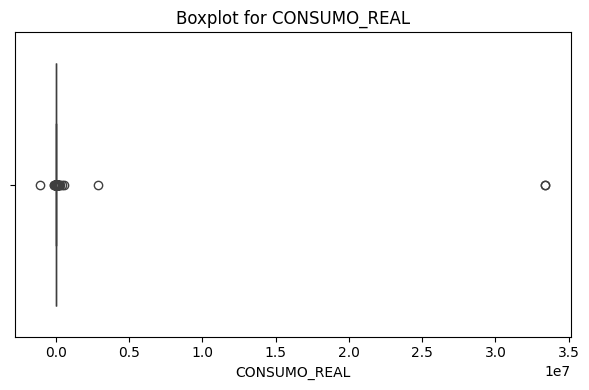

In [ ]:
print("\nGenerating boxplots for numeric columns...")
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_ab[col])
    plt.title(f"Boxplot for {col}")
    plt.tight_layout()
    plt.show()


Generating barplots for categorical columns...


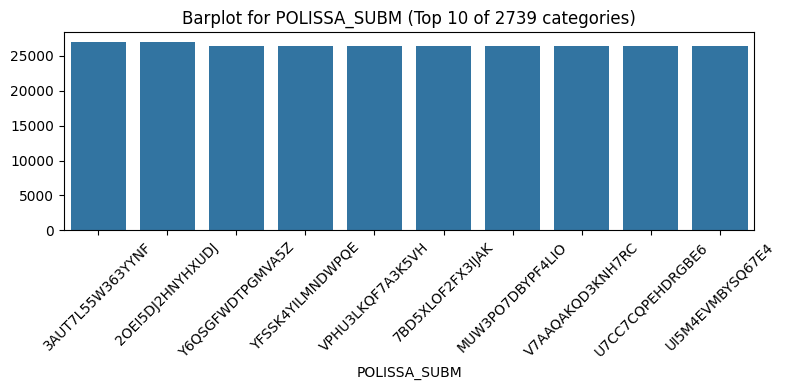

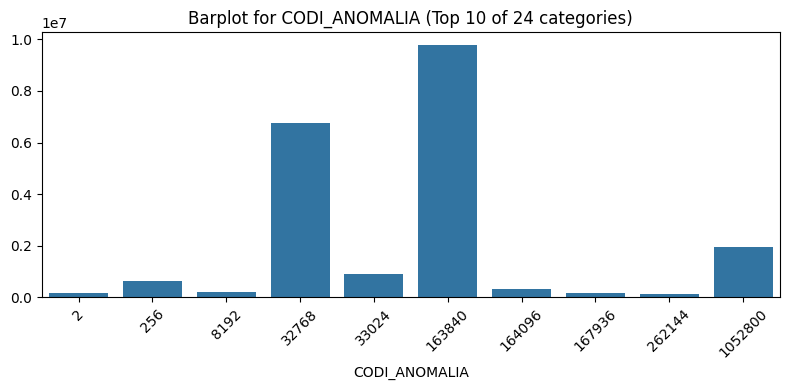

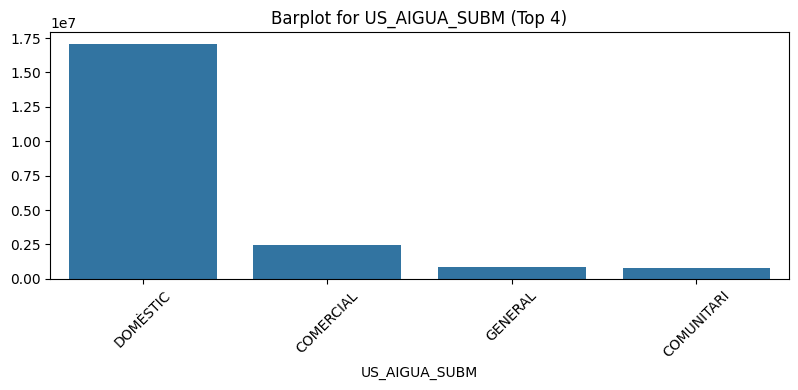

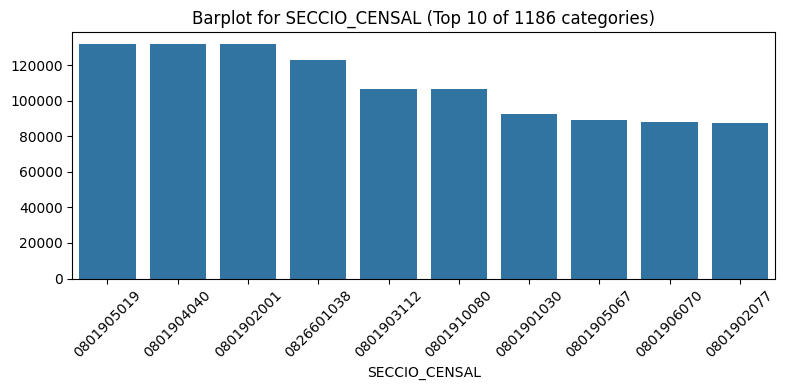

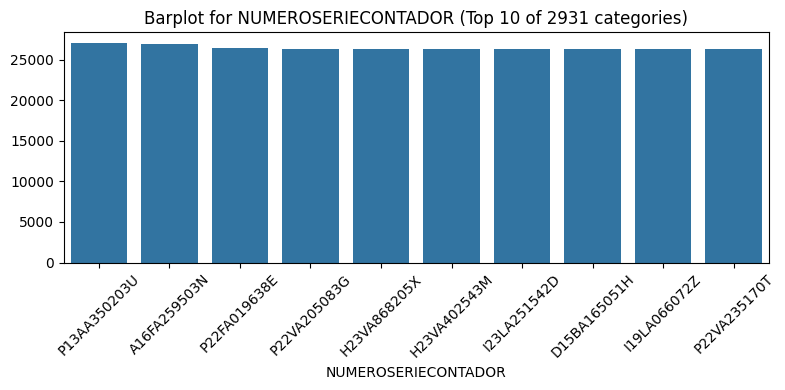

In [ ]:
print("\nGenerating barplots for categorical columns...")
for col in cat_cols:
    value_counts = df_ab[col].value_counts()
    n_unique = len(value_counts)

    plt.figure(figsize=(8, 4))
    if n_unique <= 10:
        sns.barplot(x=value_counts.index, y=value_counts.values)
        plt.title(f"Barplot for {col} (Top {n_unique})")
    else:
        sns.barplot(x=value_counts.head(10).index, y=value_counts.head(10).values)
        plt.title(f"Barplot for {col} (Top 10 of {n_unique} categories)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Generating time distribution plots for datetime columns...


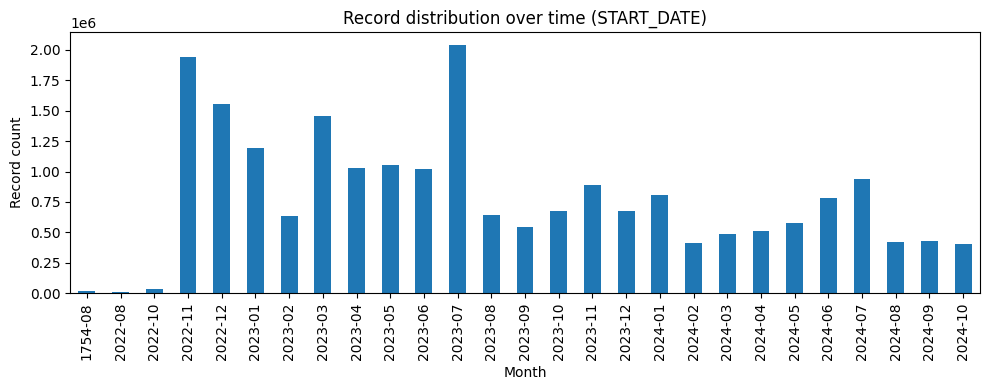

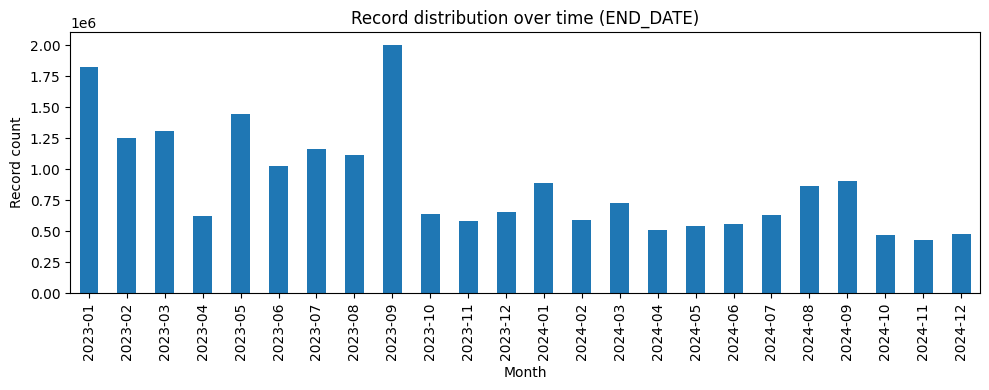

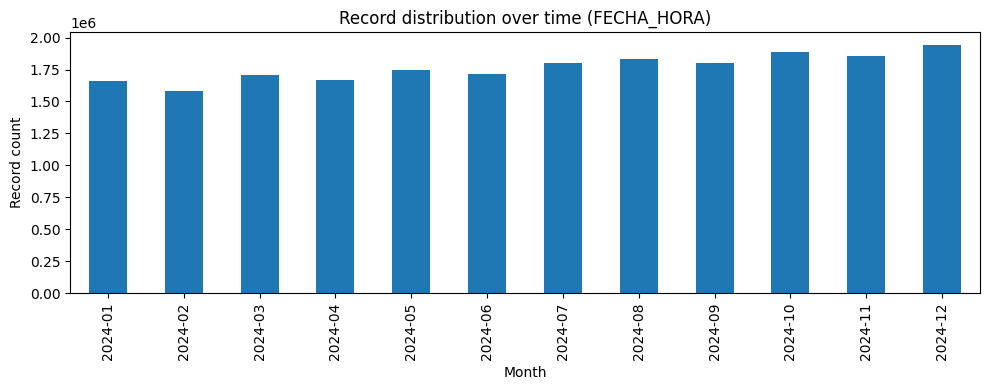

In [ ]:
print("\nGenerating time distribution plots for datetime columns...")

for col in date_cols:
    plt.figure(figsize=(10, 4))
    df_ab[col].dt.to_period('M').value_counts().sort_index().plot(kind='bar')
    plt.title(f"Record distribution over time ({col})")
    plt.xlabel("Month")
    plt.ylabel("Record count")
    plt.tight_layout()
    plt.show()

## Correlation

In [ ]:
# Numeric columns
numeric_cols = ['CONSUMO_REAL']
# Categorical columns
cat_cols = ['POLISSA_SUBM', 'US_AIGUA_SUBM', 'SECCIO_CENSAL', 'NUMEROSERIECONTADOR']
# Date columns
date_cols = ['START_DATE', 'END_DATE', 'FECHA_HORA']
# Target column
target_col = 'CODI_ANOMALIA'

# Get unique anomaly codes (sorted for readability)
anomaly_types = sorted(df_ab[target_col].unique())


Generating numeric distribution boxplots by CODI_ANOMALIA...


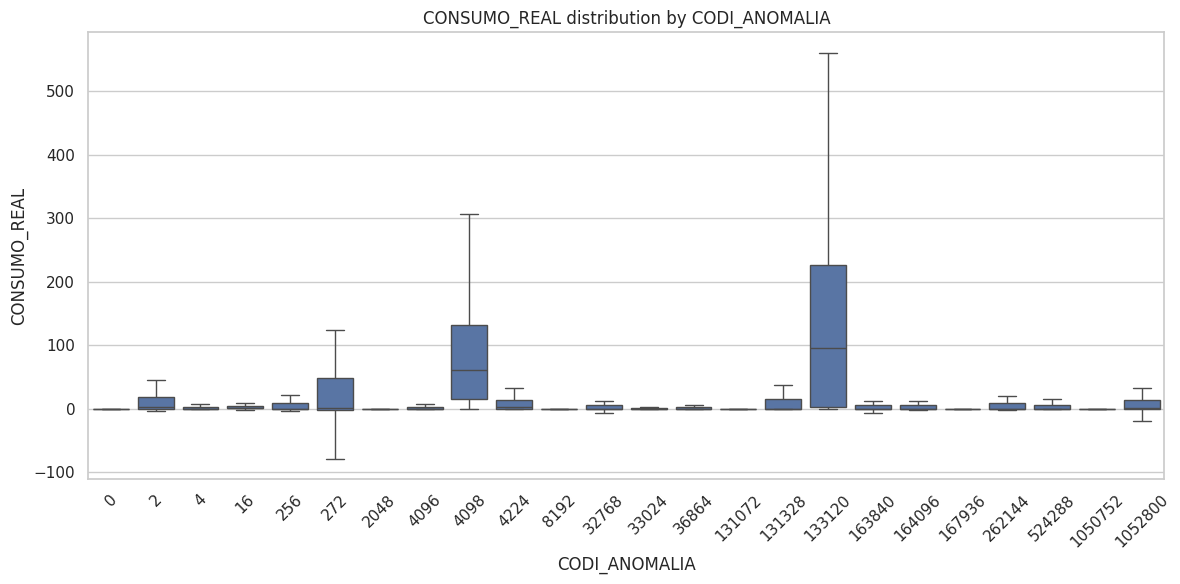

In [ ]:
print("\nGenerating numeric distribution boxplots by CODI_ANOMALIA...")

for num_col in numeric_cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_ab,
        x=target_col,
        y=num_col,
        showfliers=False  # remove outliers from the visualization (not from the data)
    )
    plt.title(f"{num_col} distribution by {target_col}")
    plt.xlabel(target_col)
    plt.ylabel(num_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Generating categorical barplots by CODI_ANOMALIA (grouped by anomaly)...


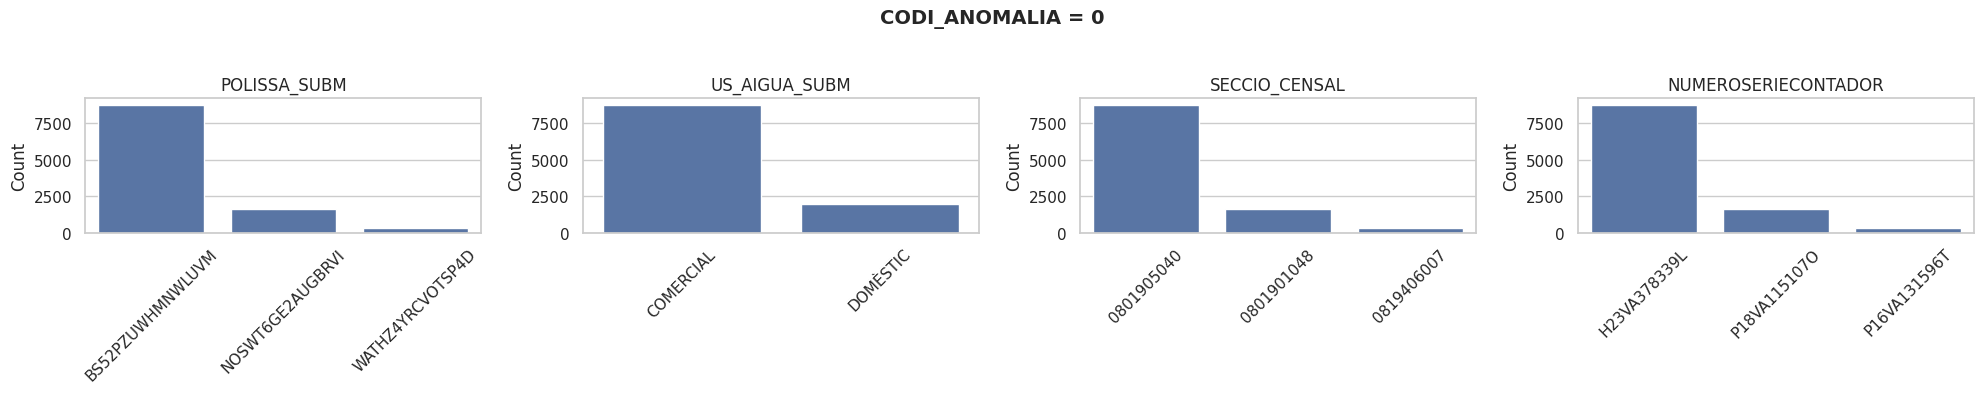

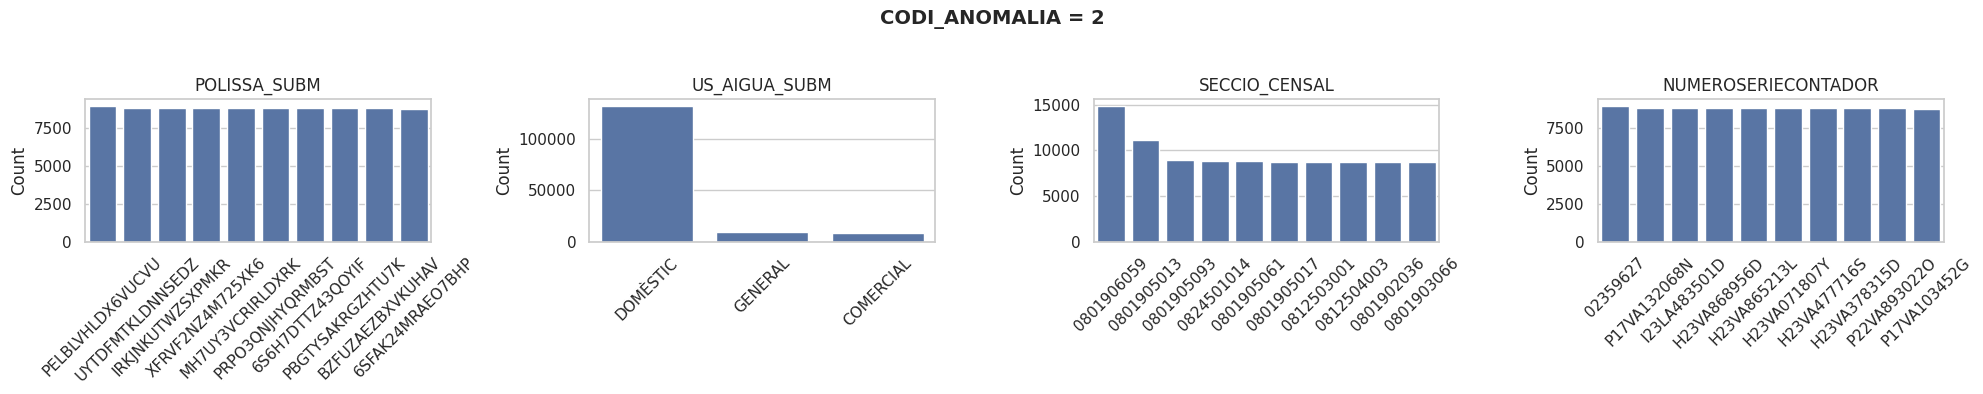

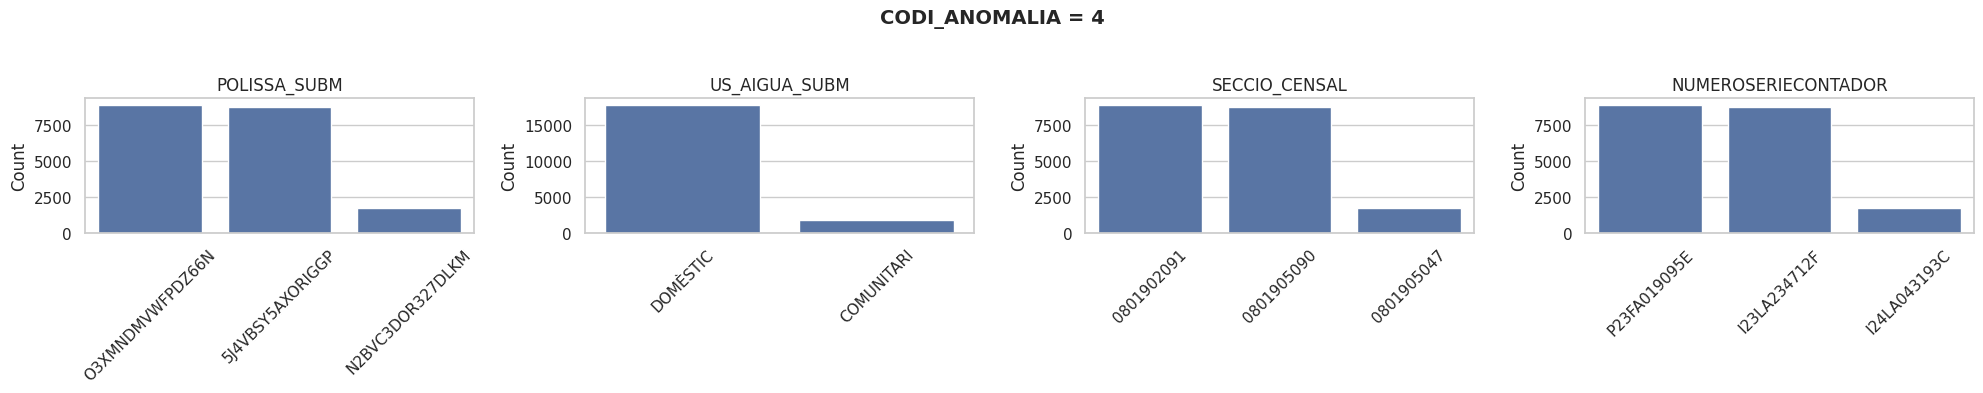

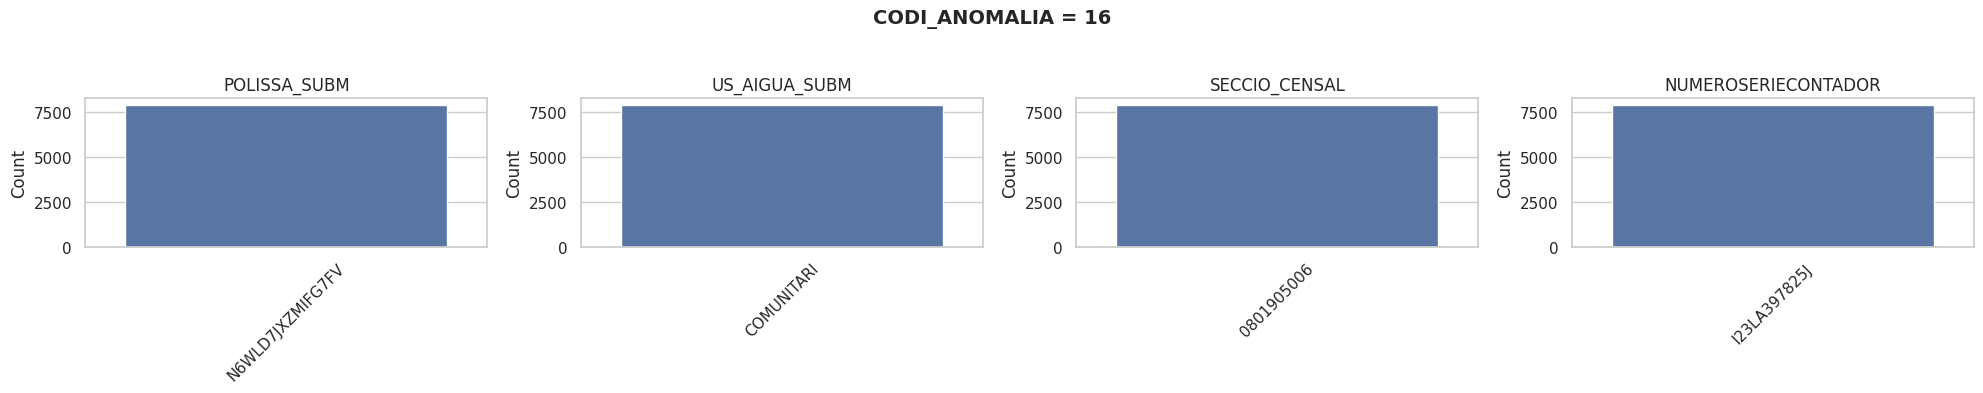

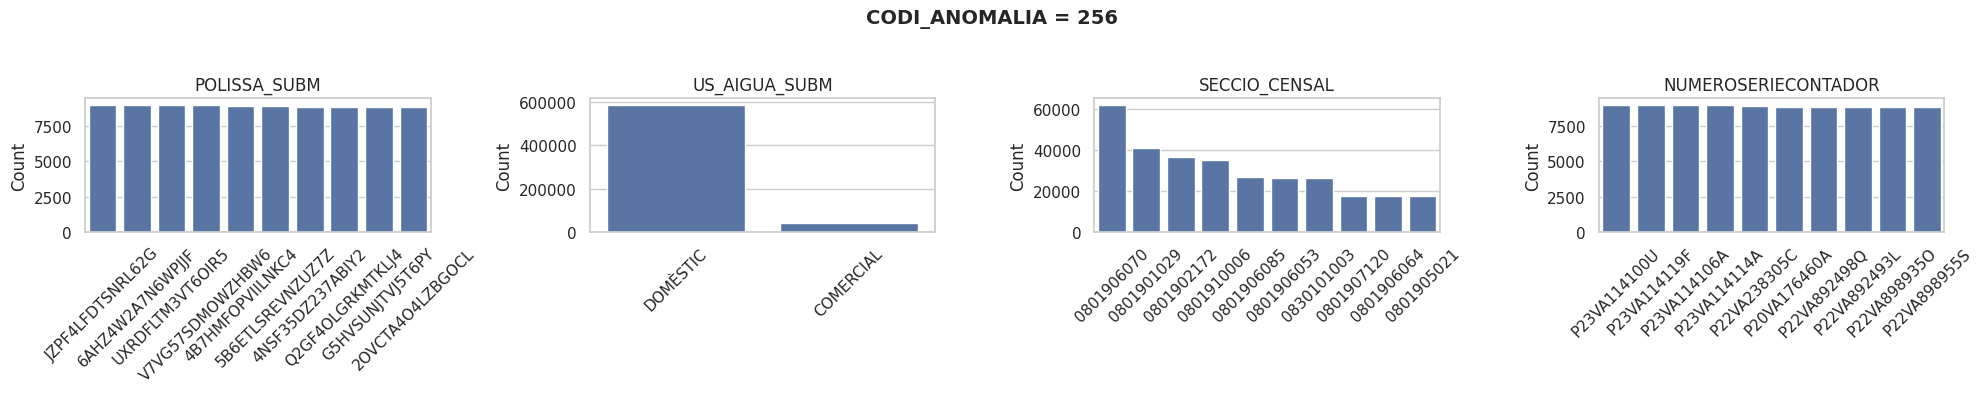

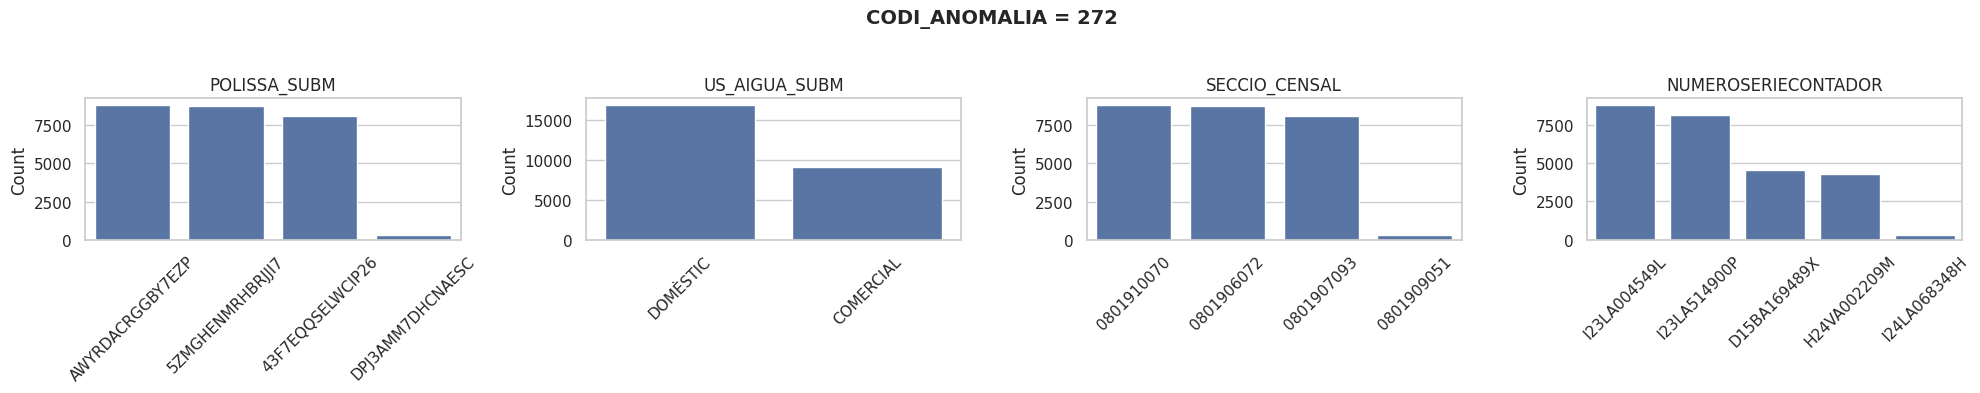

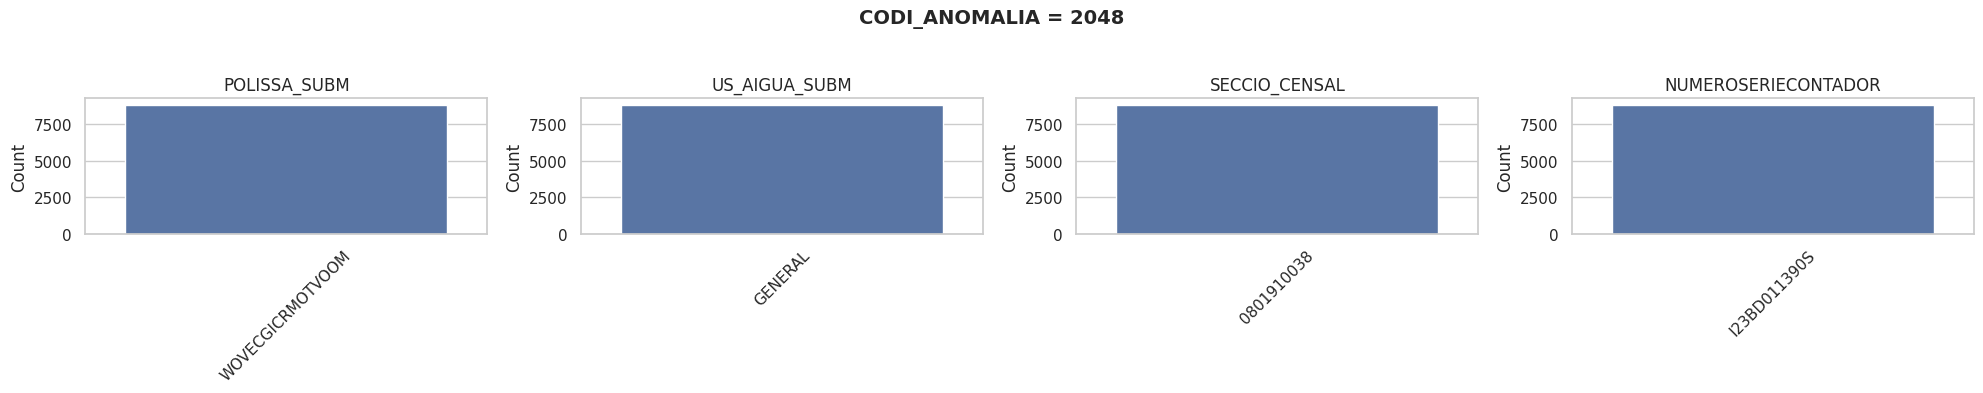

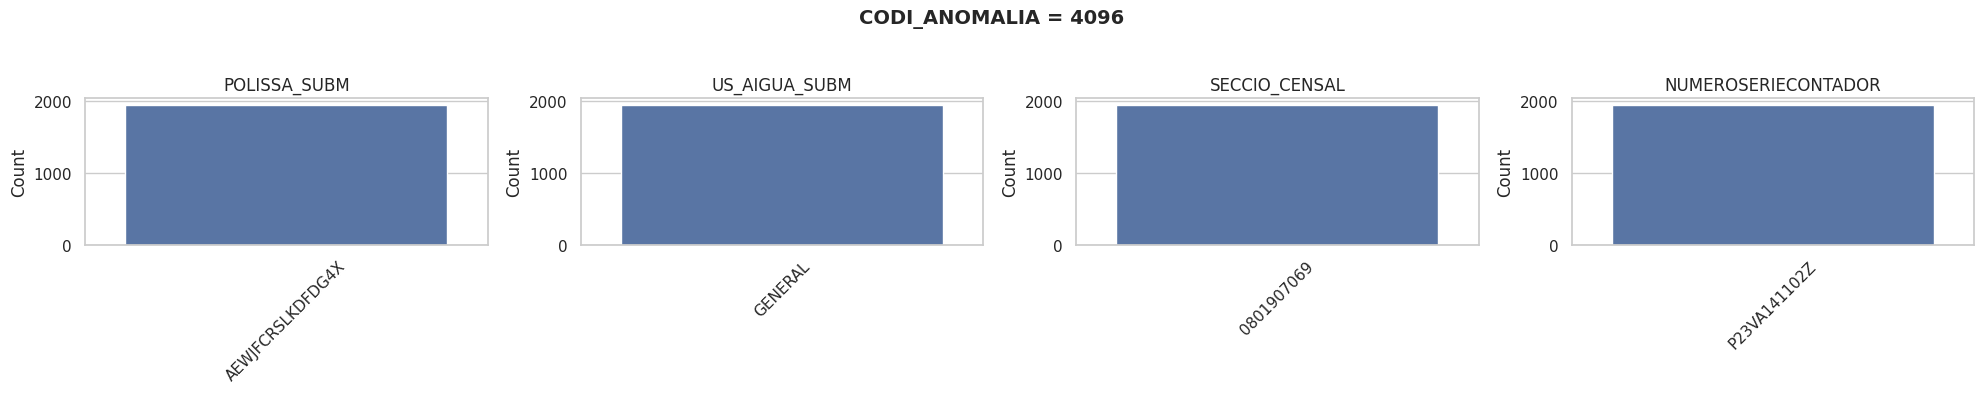

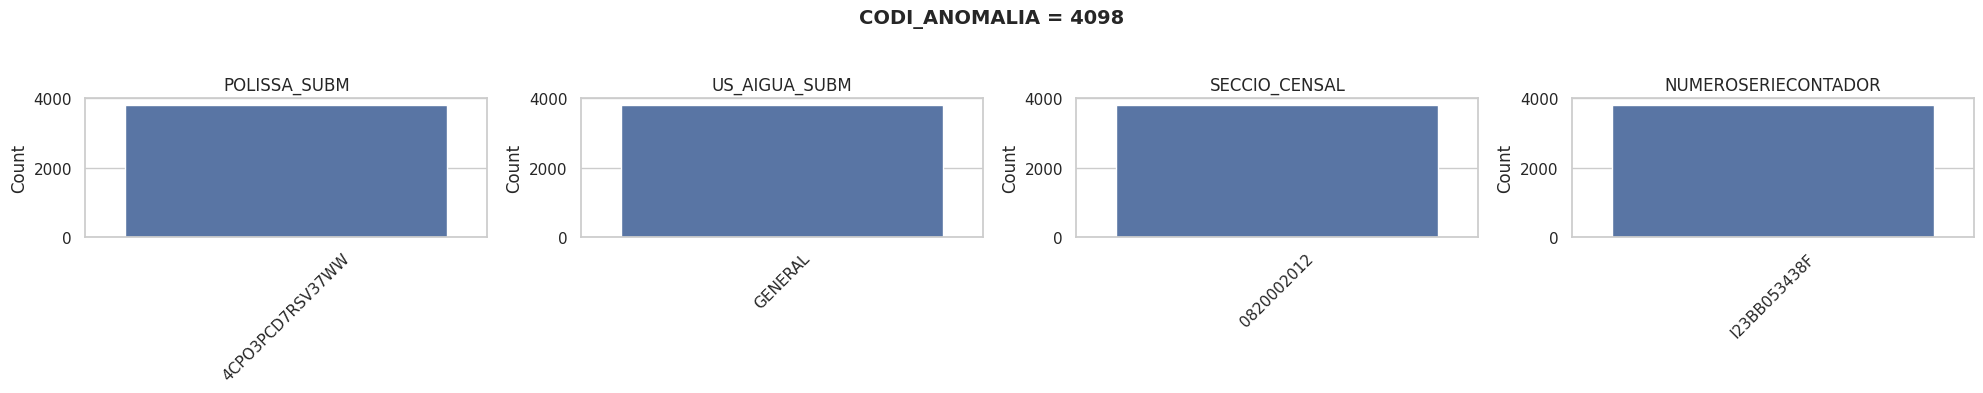

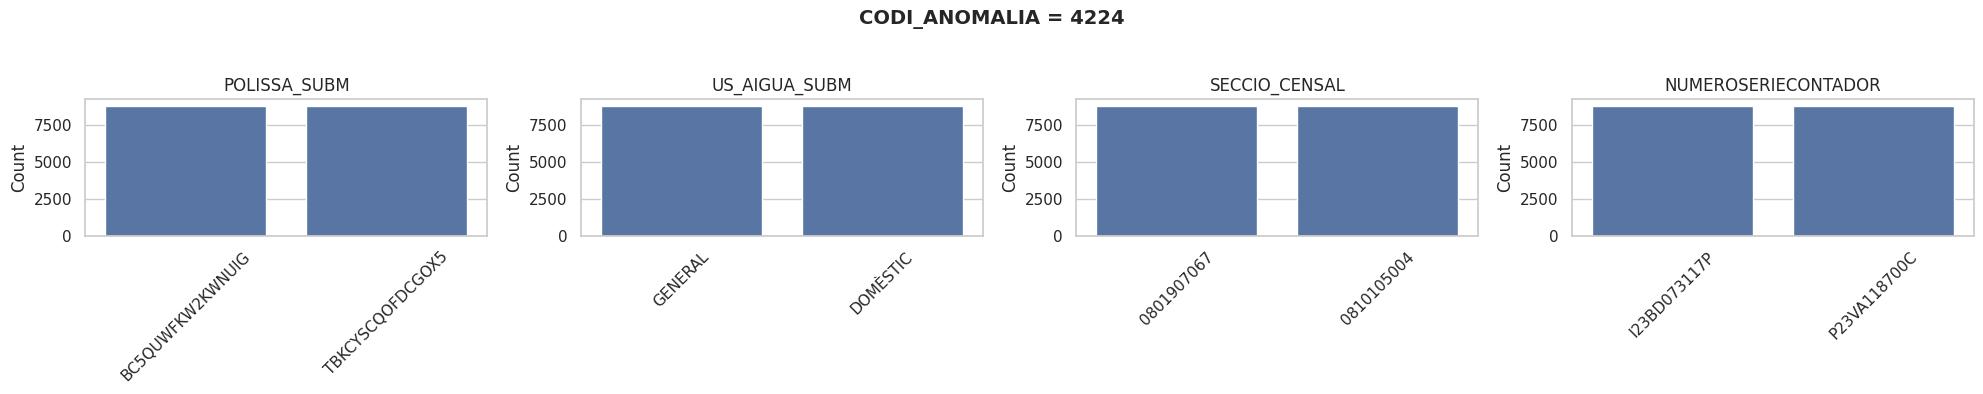

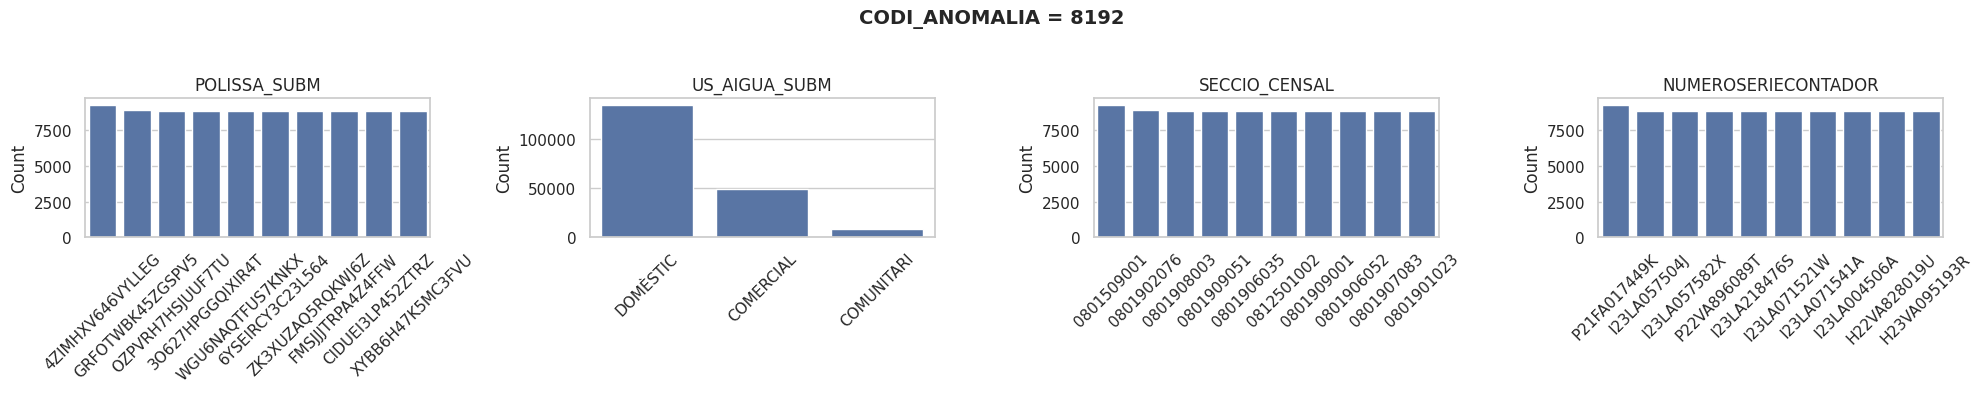

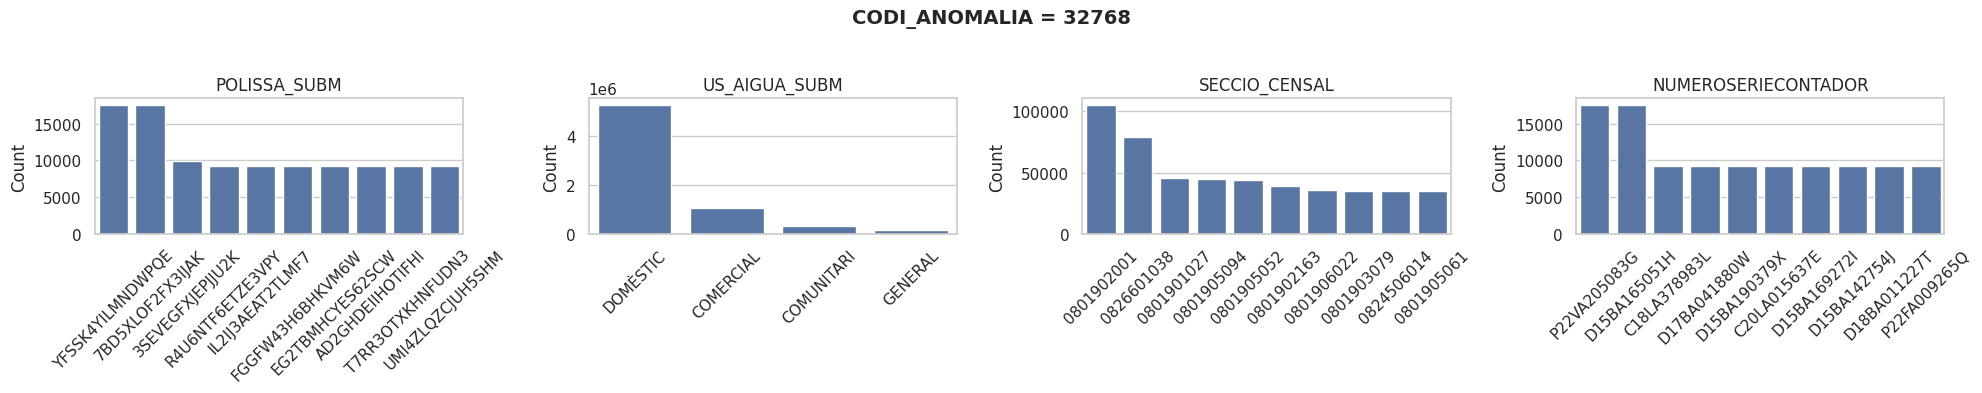

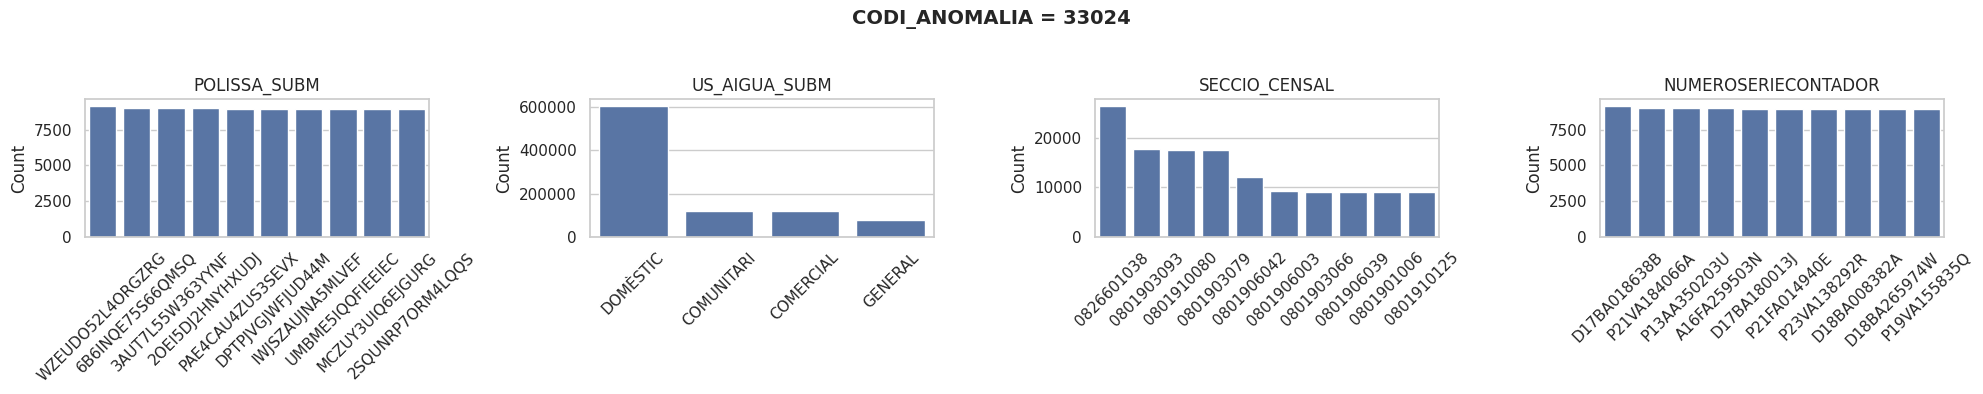

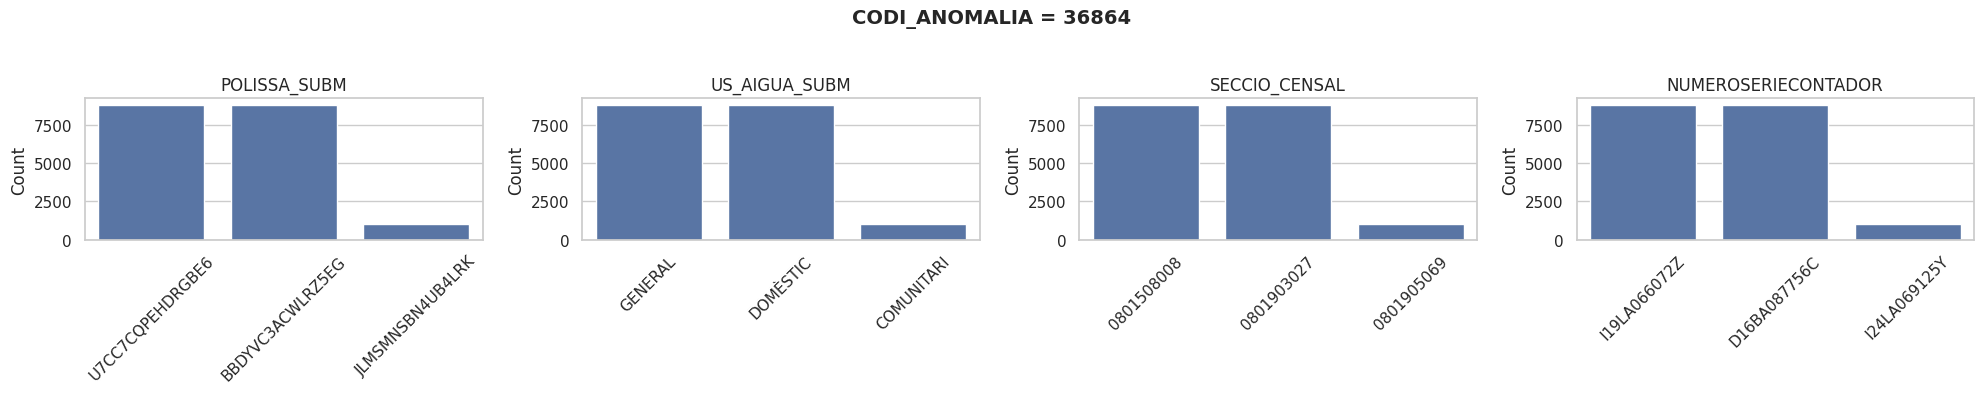

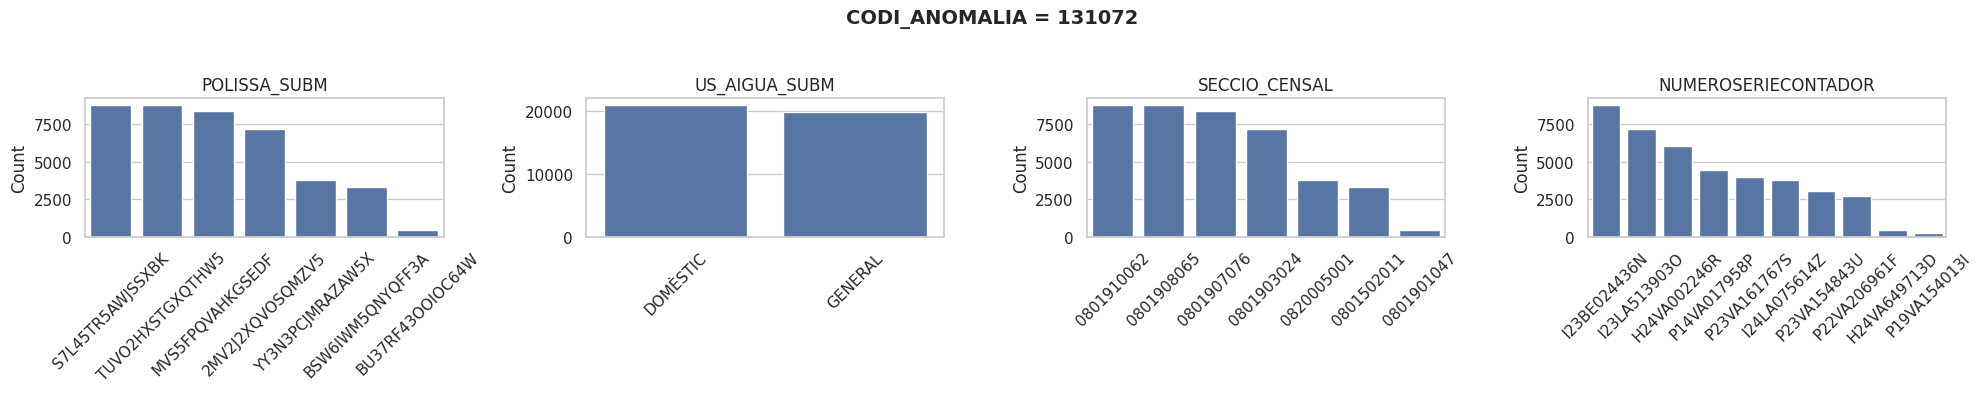

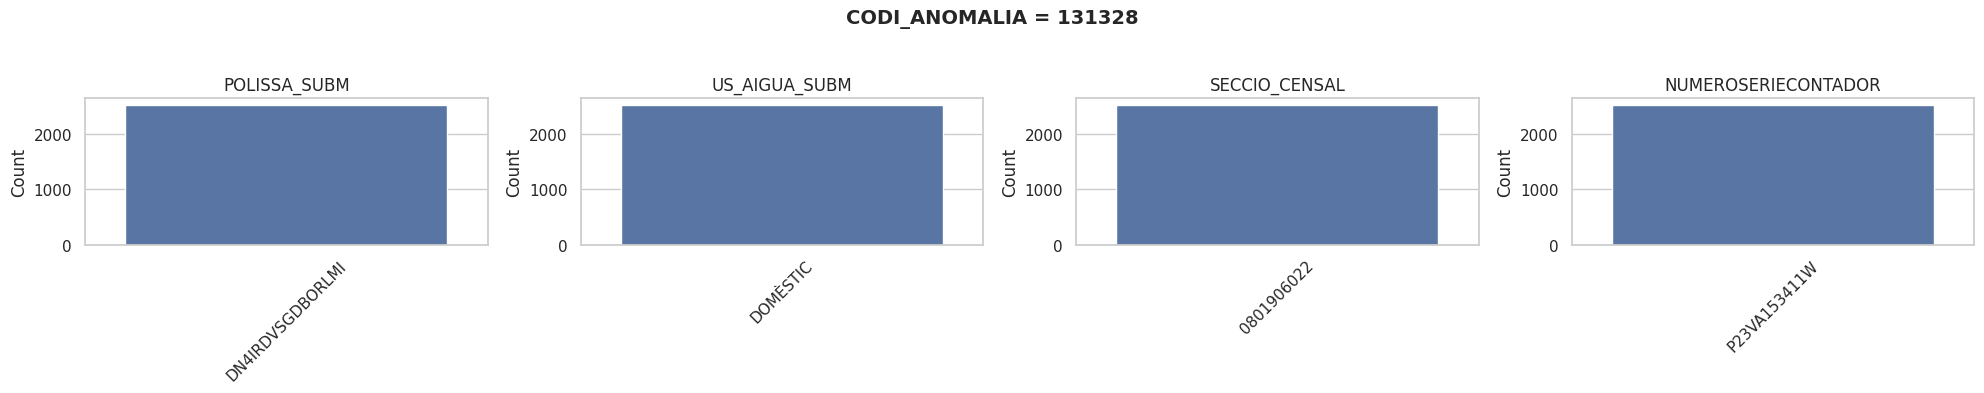

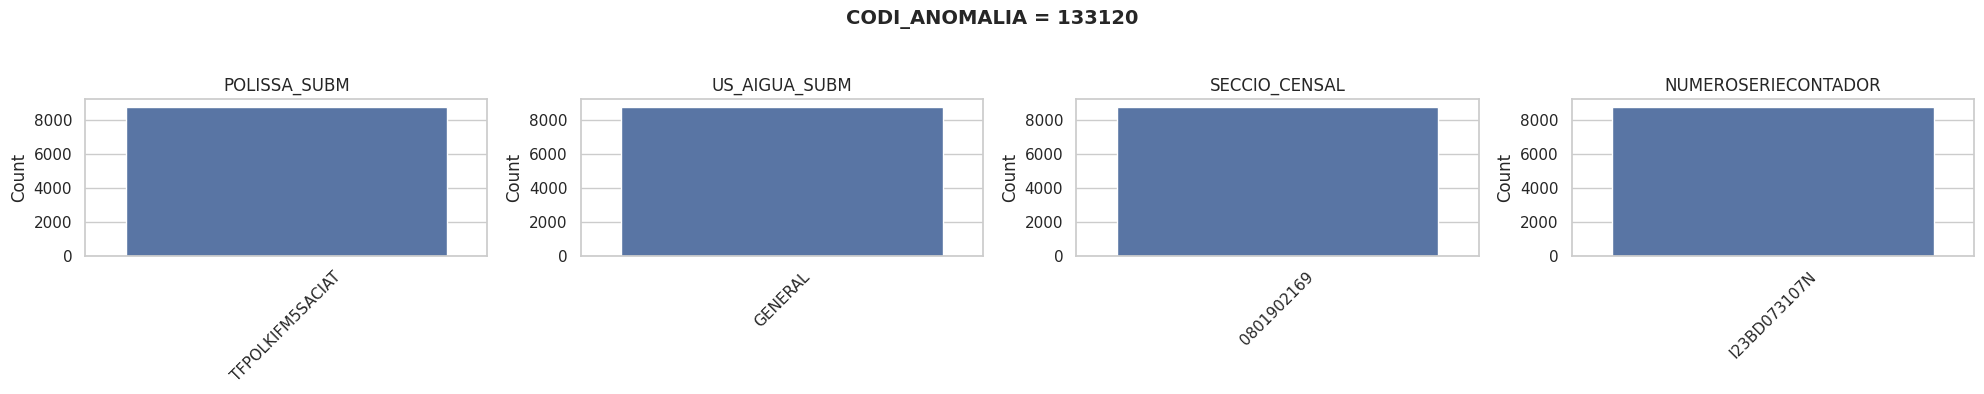

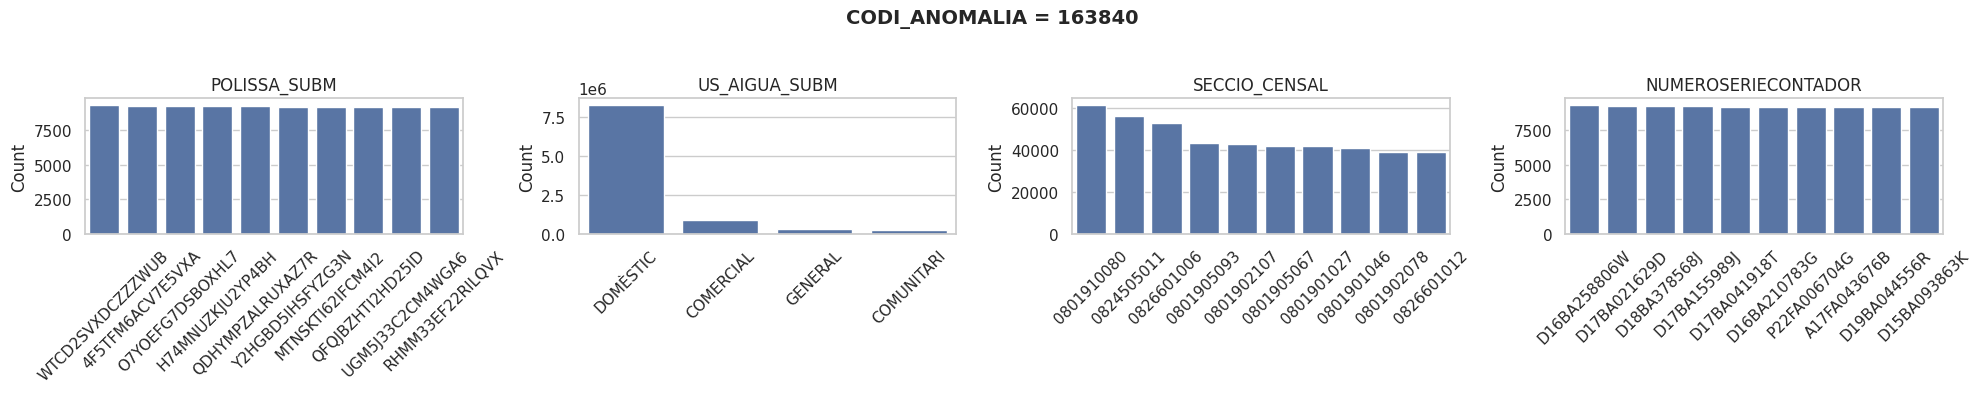

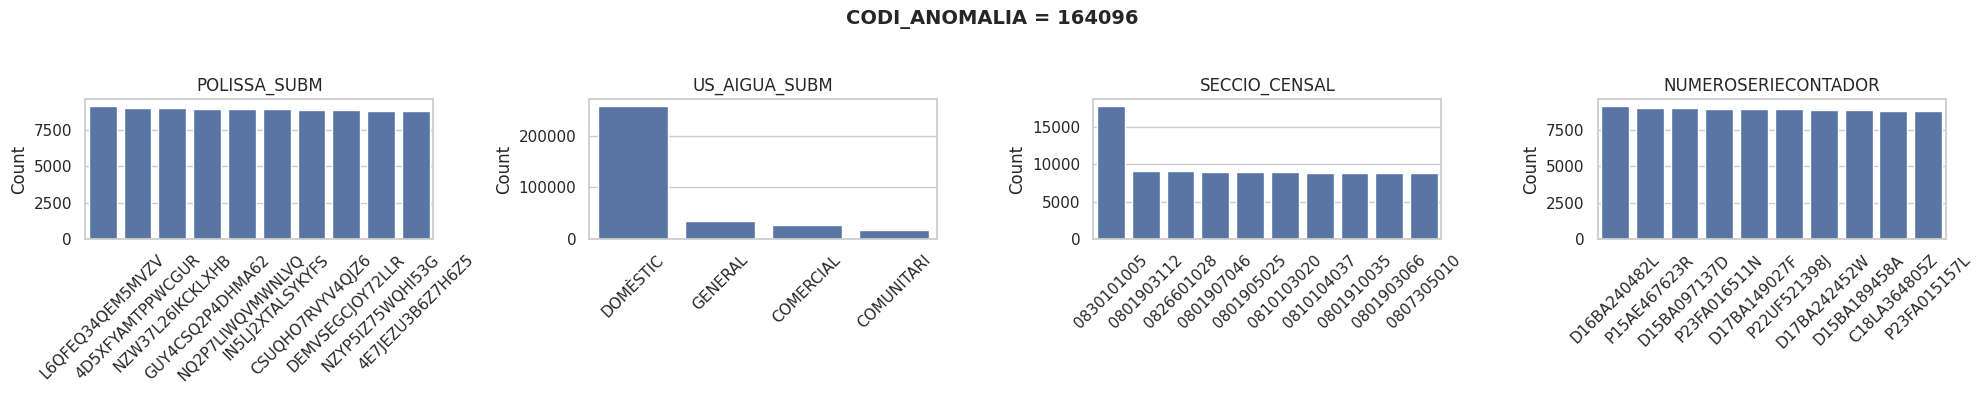

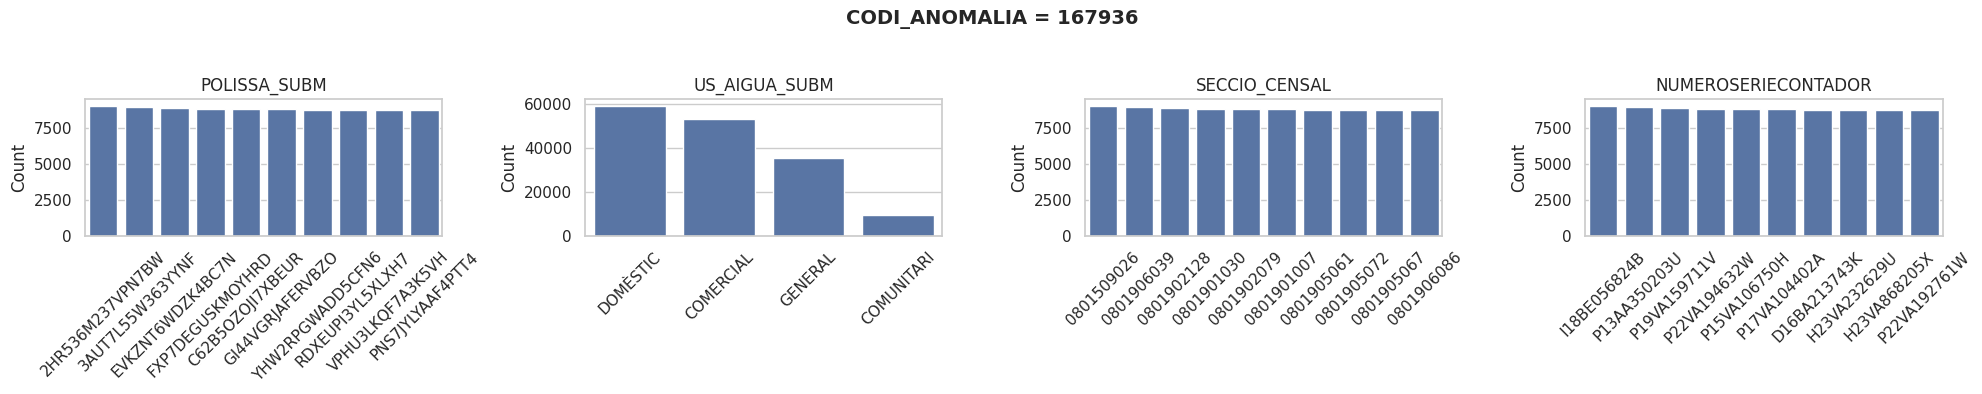

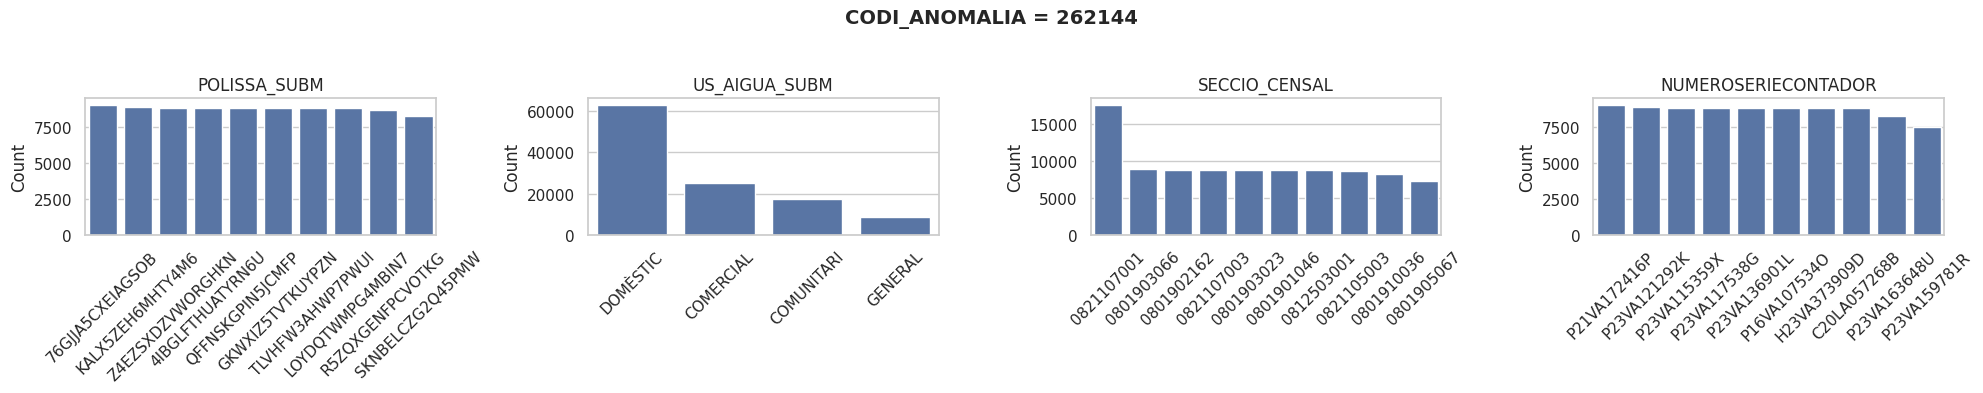

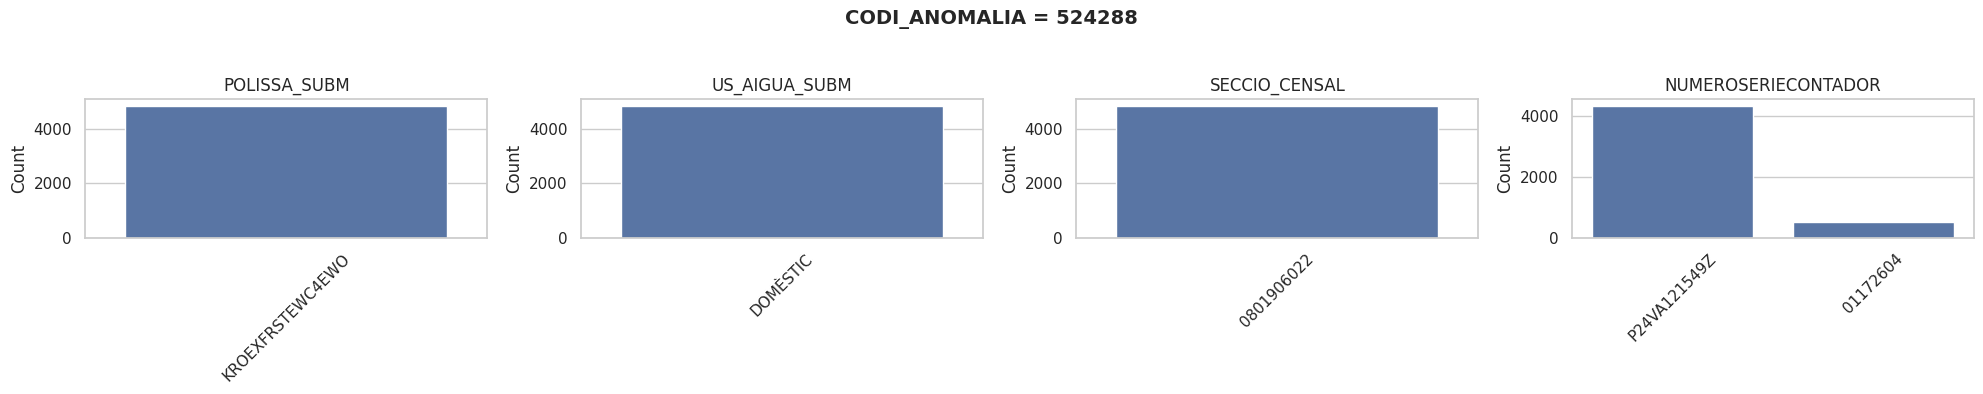

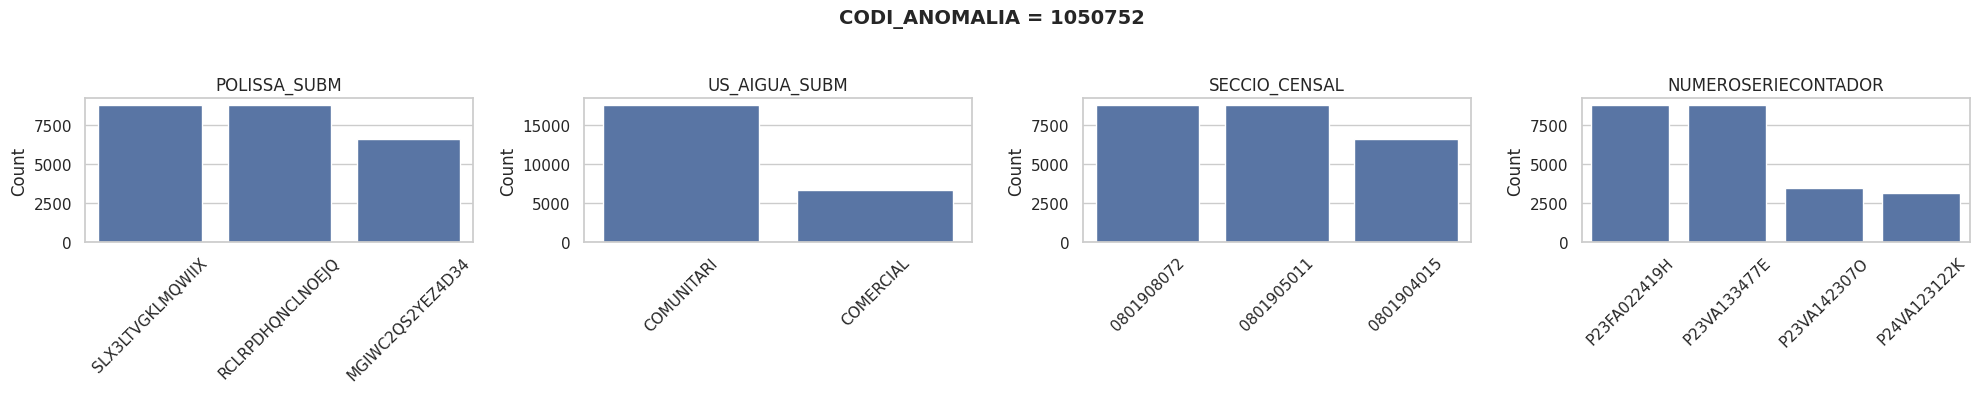

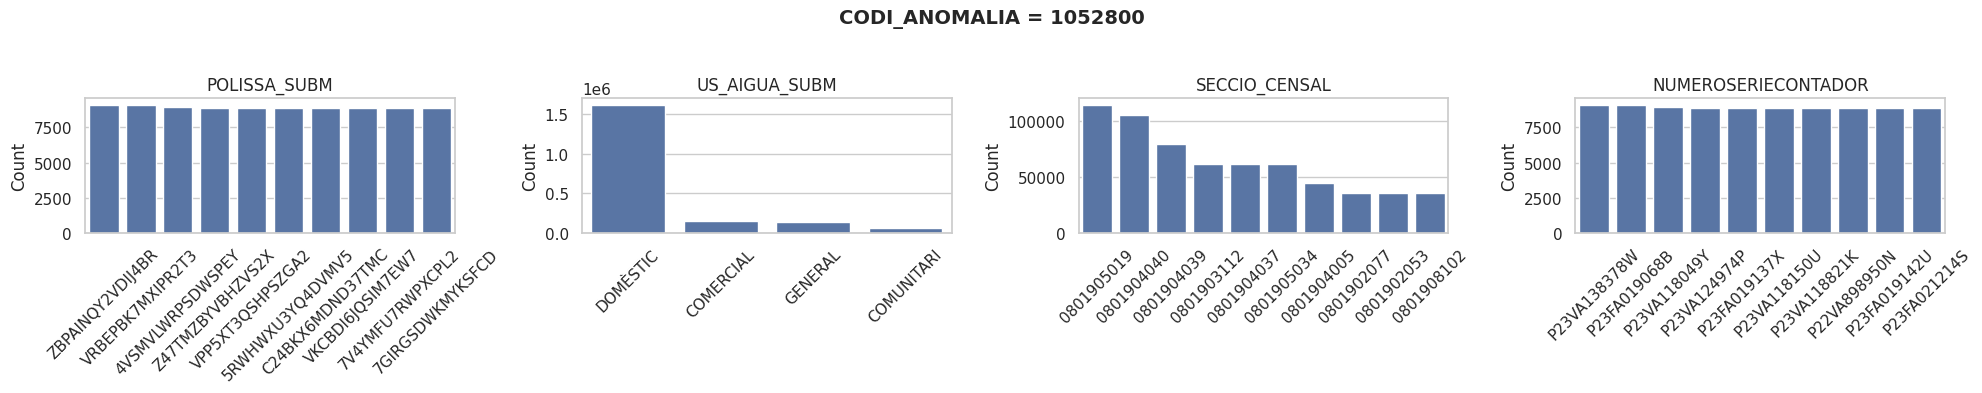

In [ ]:
print("\nGenerating categorical barplots by CODI_ANOMALIA (grouped by anomaly)...")

for anom in anomaly_types:
    subset = df_ab[df_ab[target_col] == anom]

    fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
    fig.suptitle(f"CODI_ANOMALIA = {anom}", fontsize=14, fontweight="bold")

    for i, cat in enumerate(cat_cols):
        ax = axes[i]

        # Limit to top 10 categories for clarity
        order = subset[cat].value_counts().index[:10]
        sns.countplot(
            data=subset,
            x=cat,
            order=order,
            ax=ax
        )
        ax.set_title(cat)
        ax.set_xlabel("")
        ax.set_ylabel("Count")
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Generating date distribution plots by CODI_ANOMALIA (grouped by anomaly)...


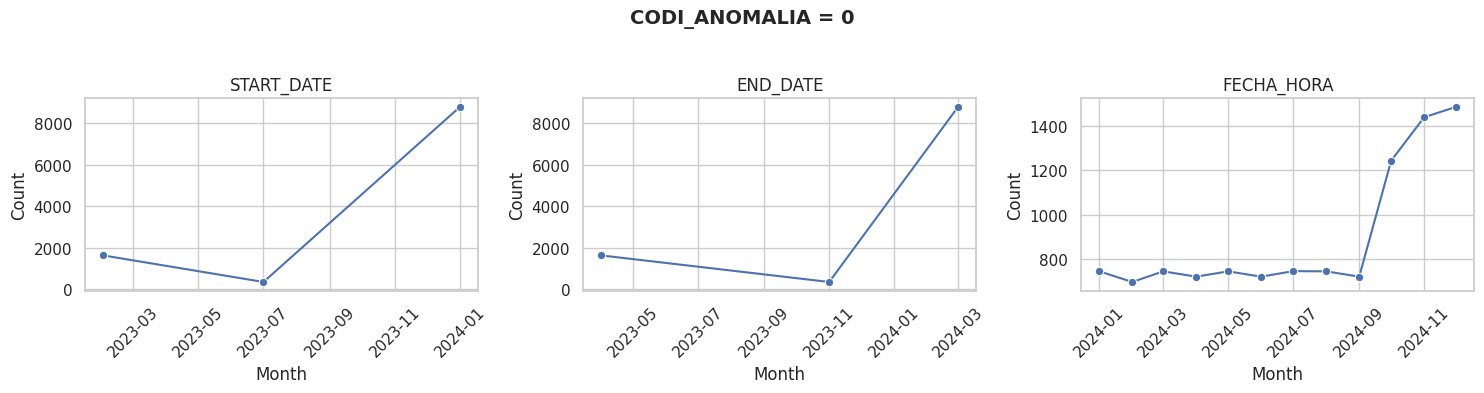

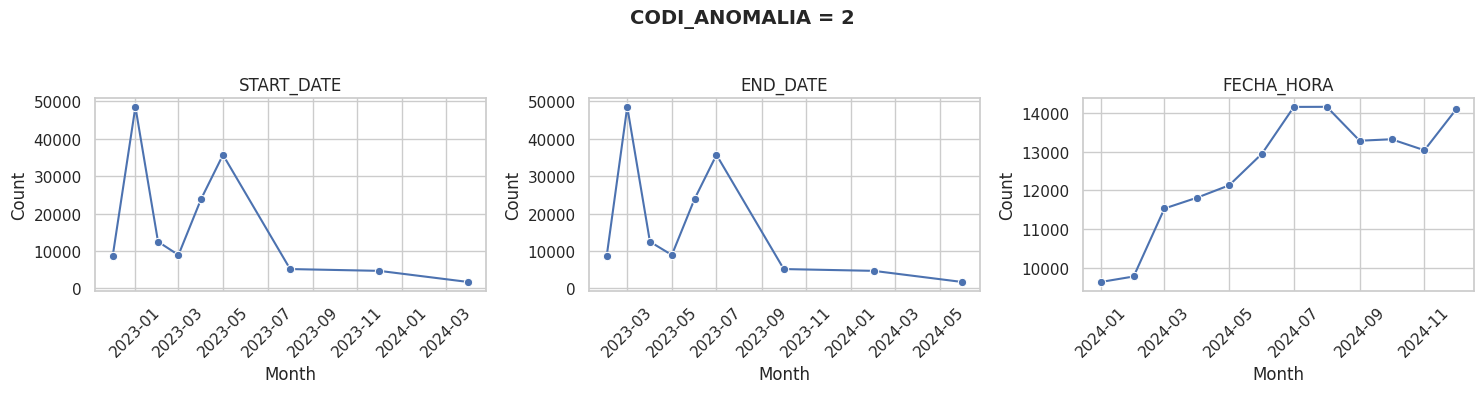

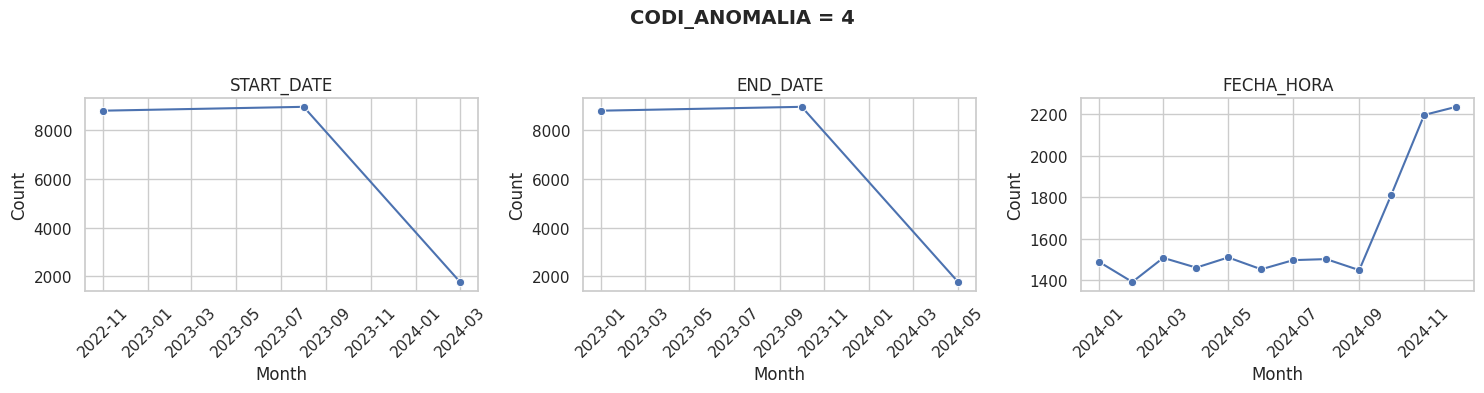

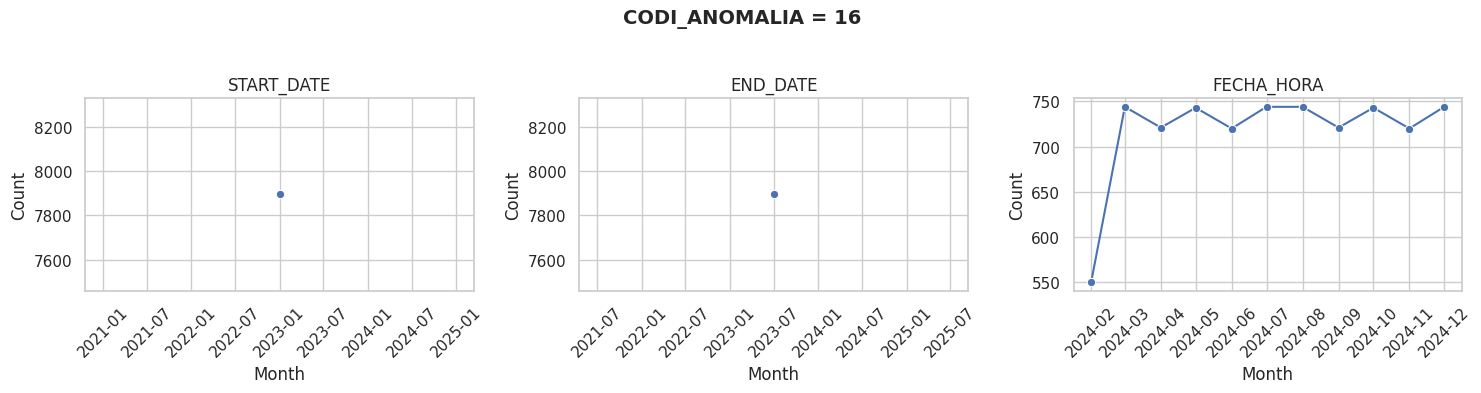

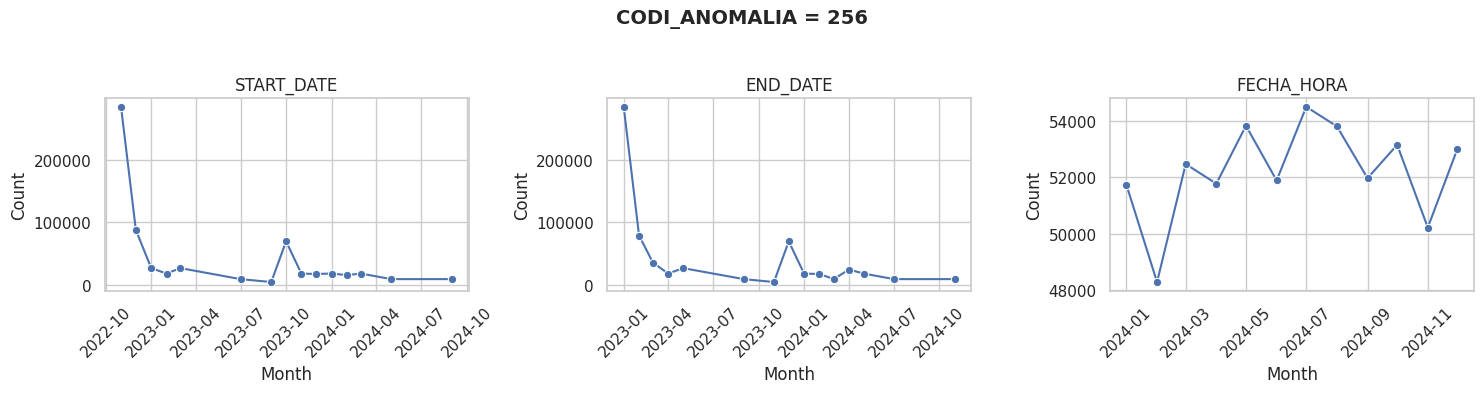

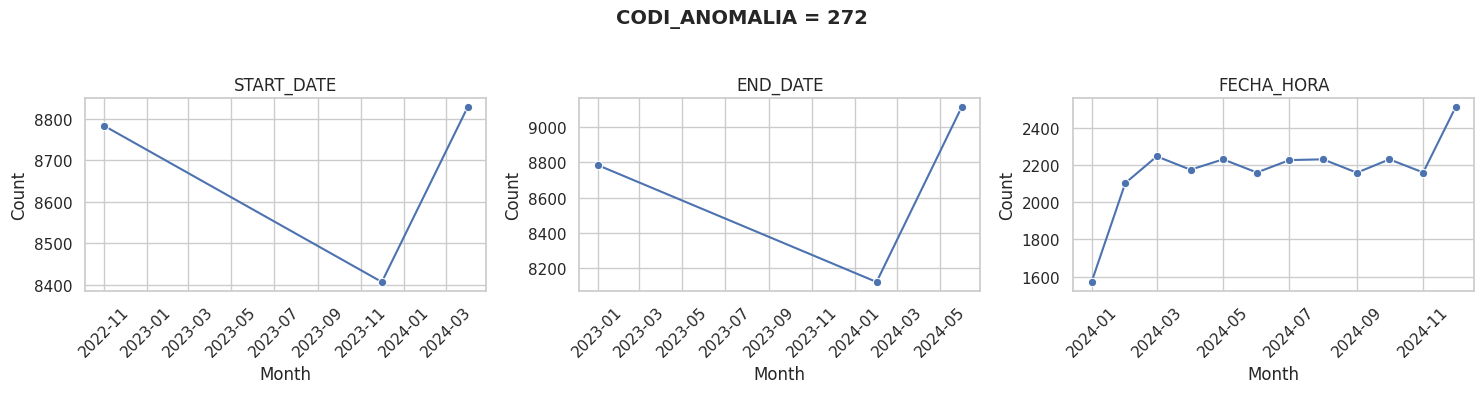

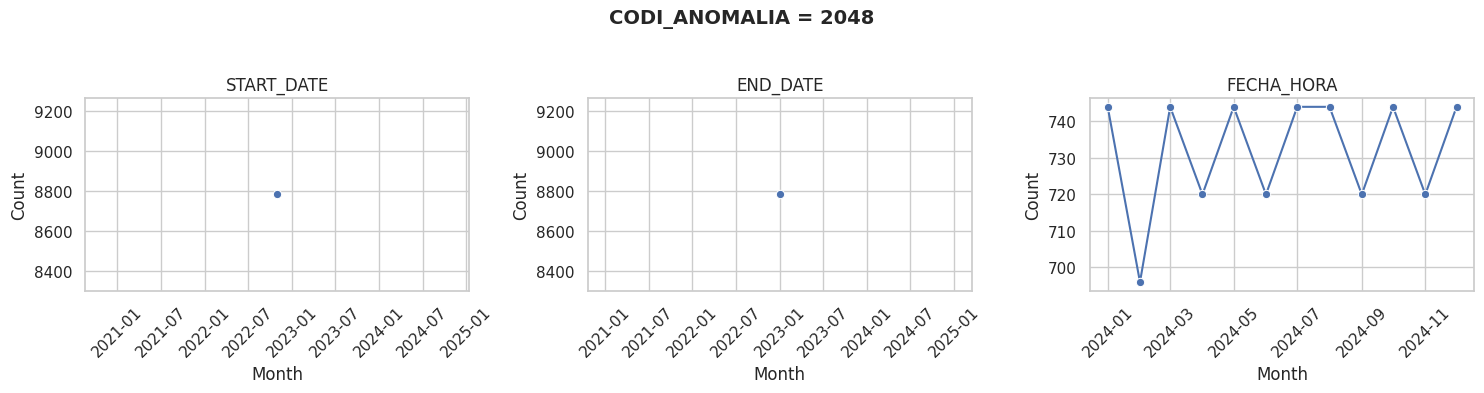

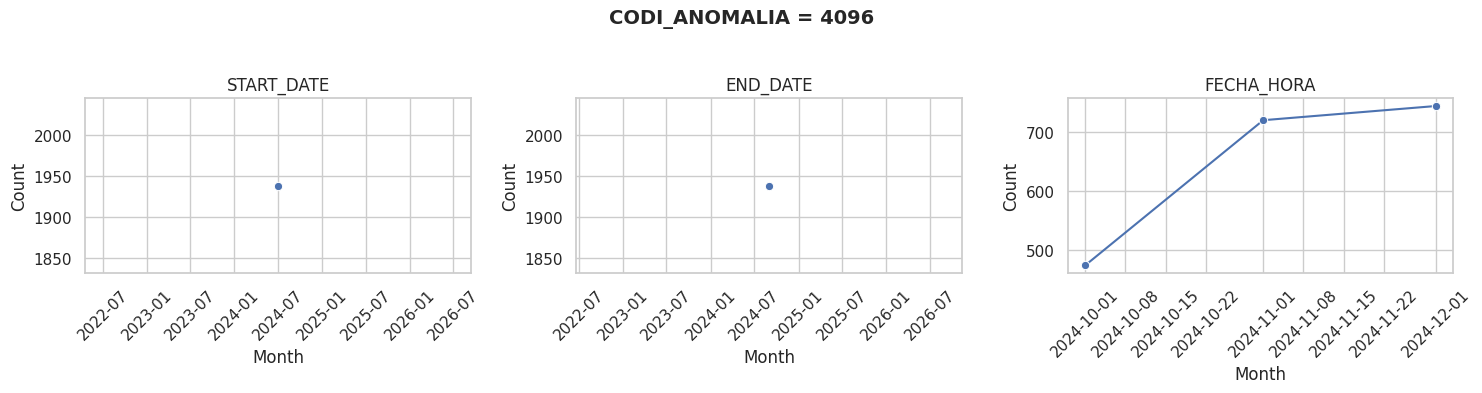

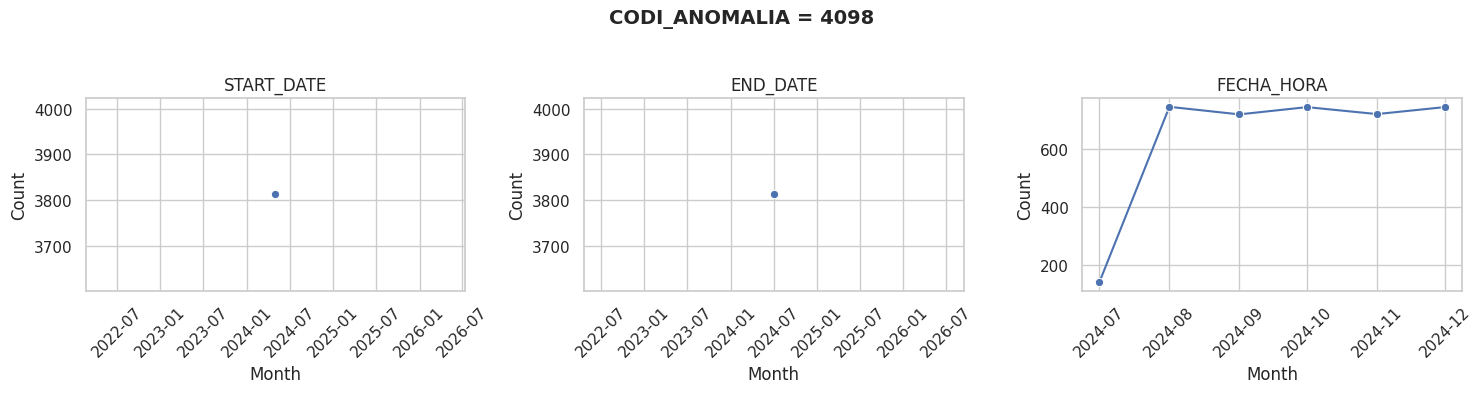

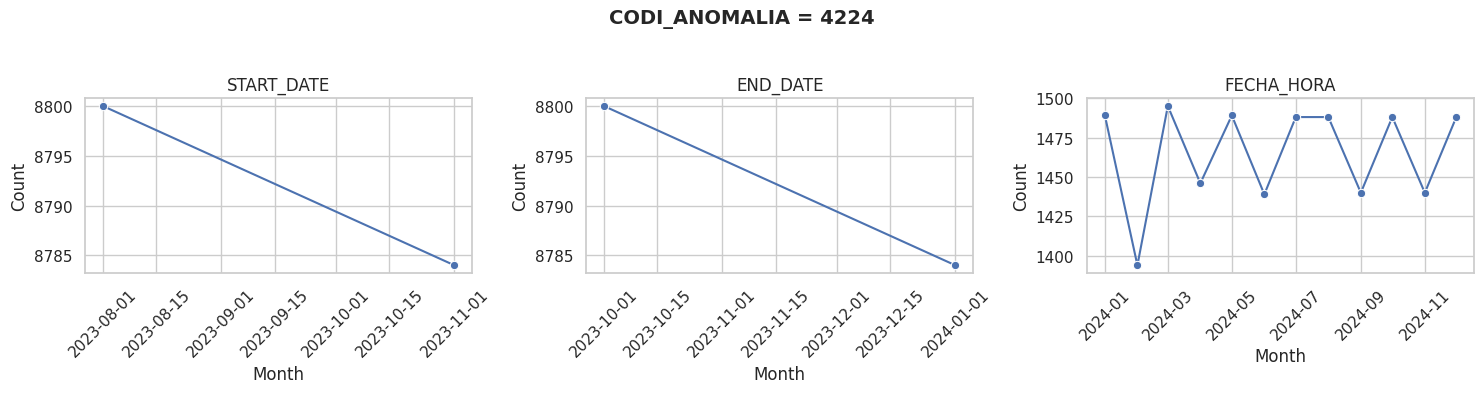

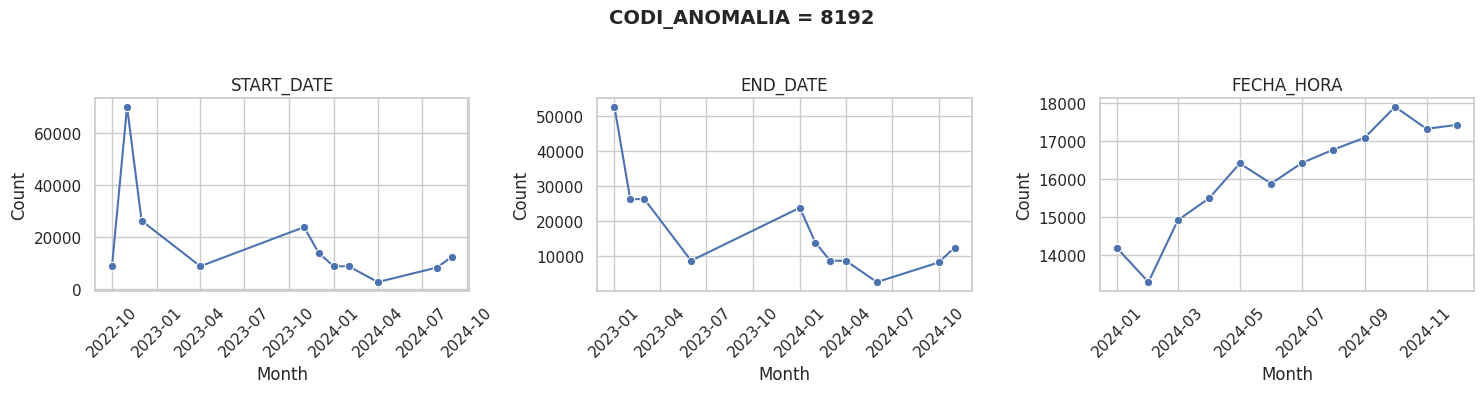

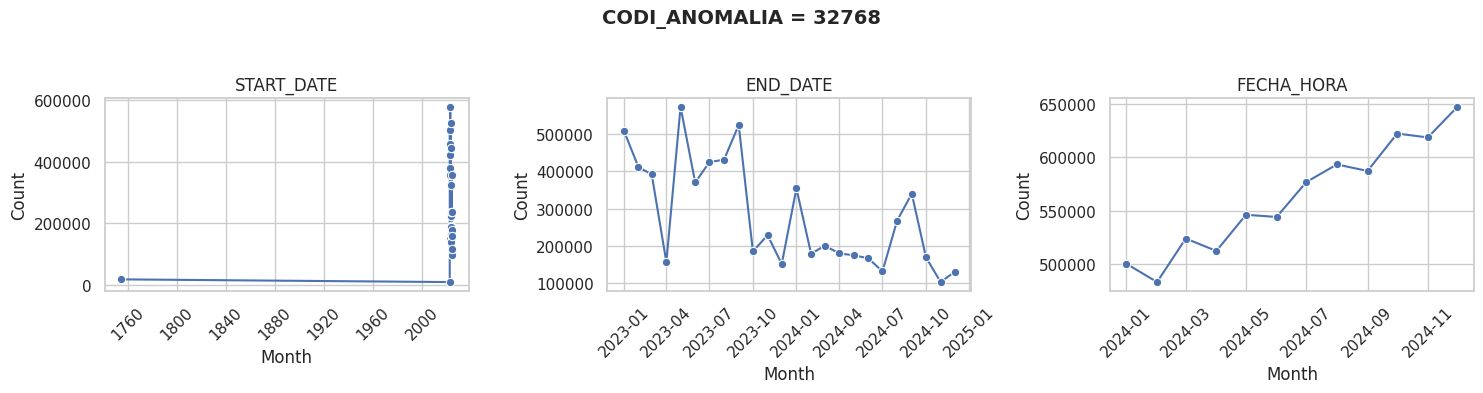

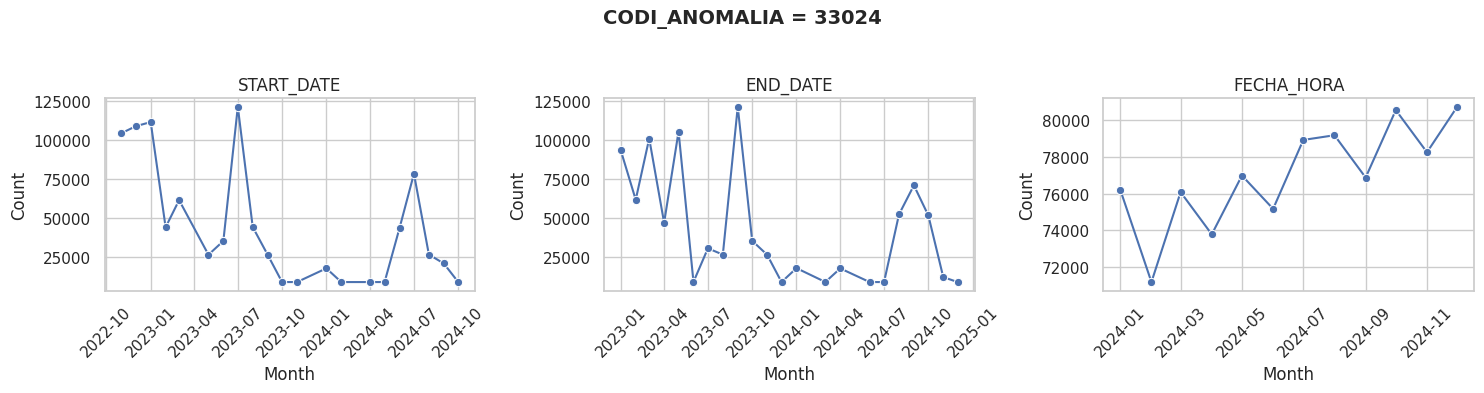

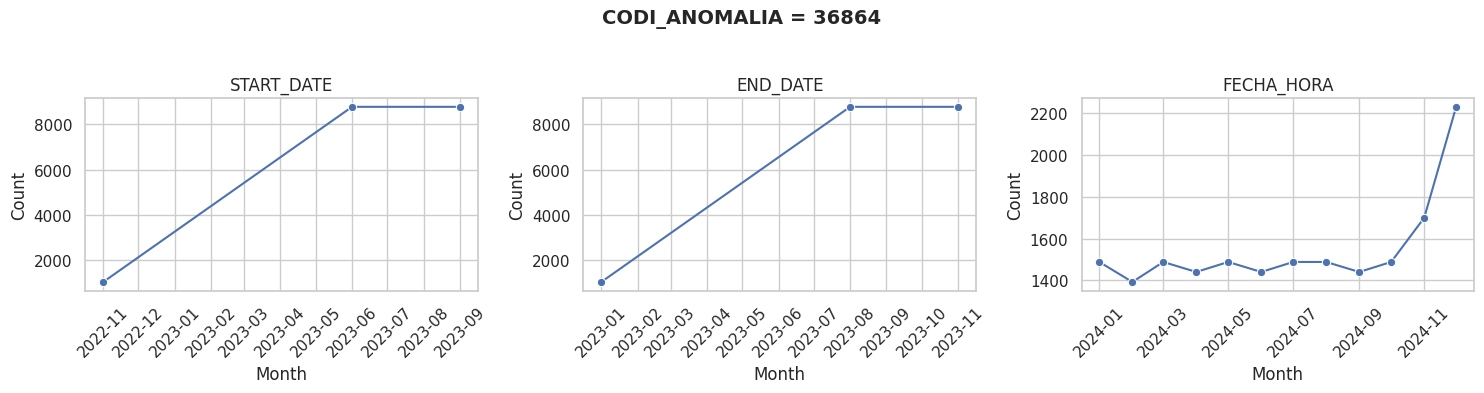

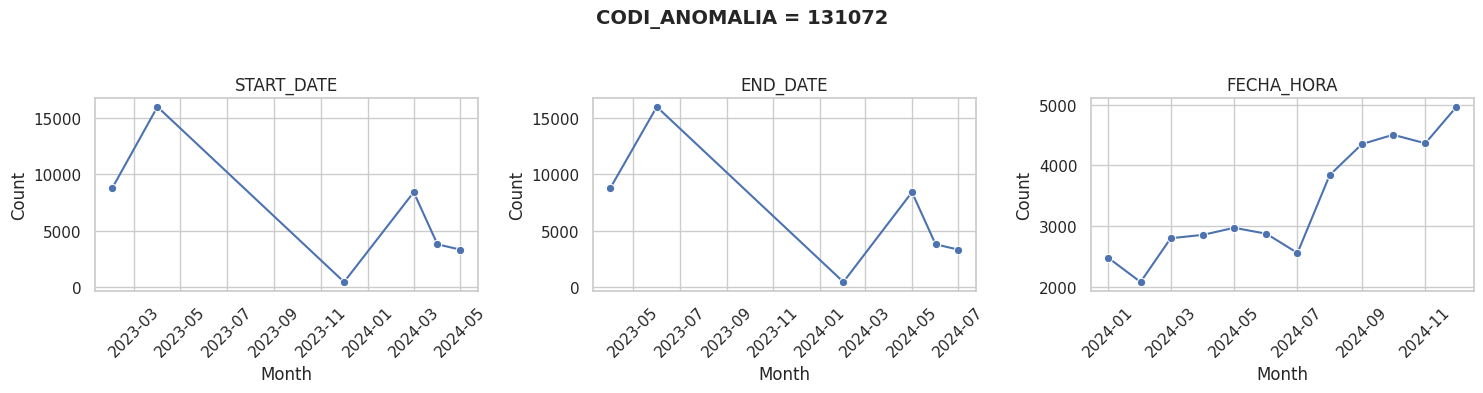

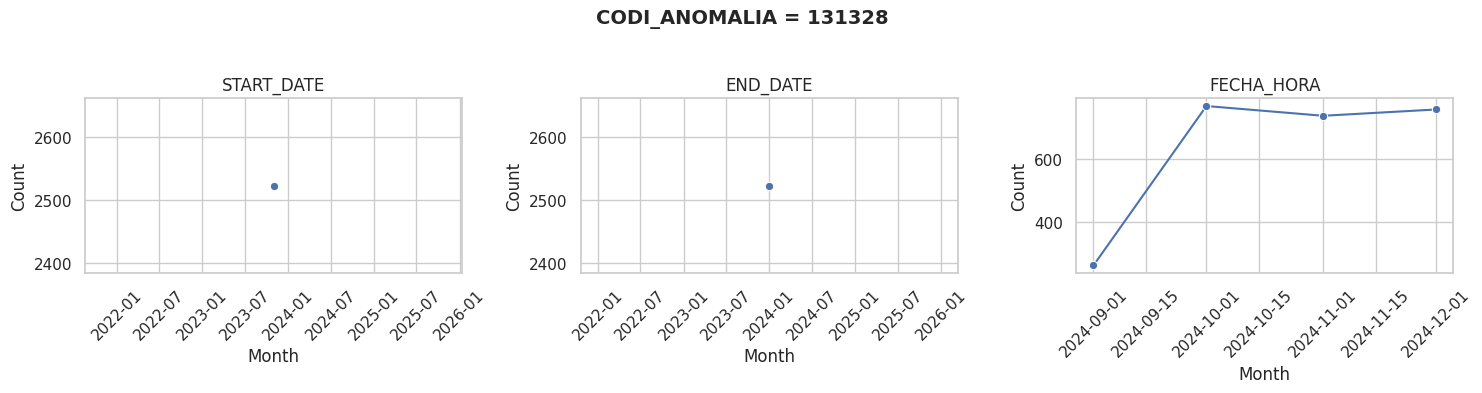

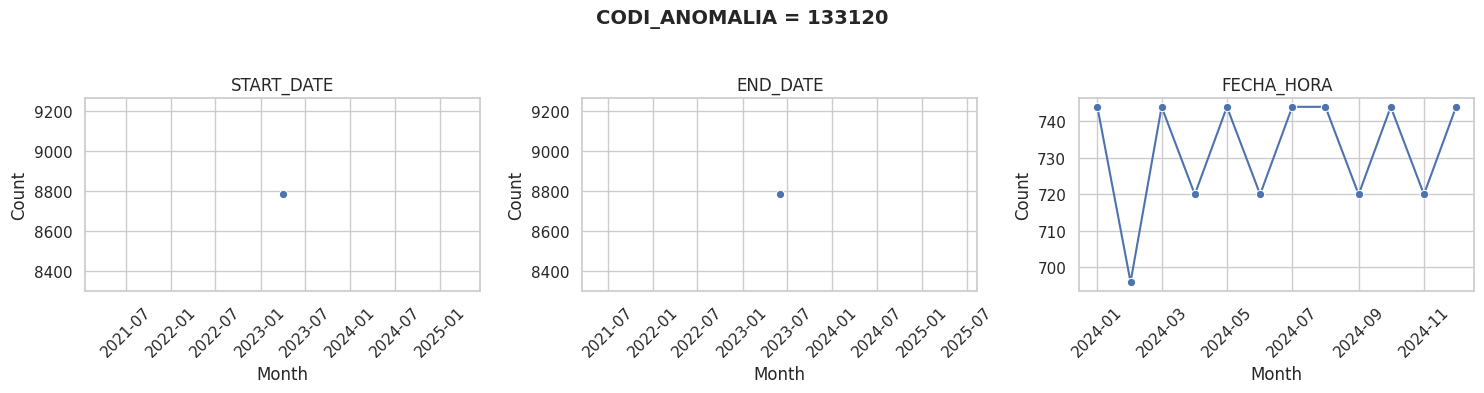

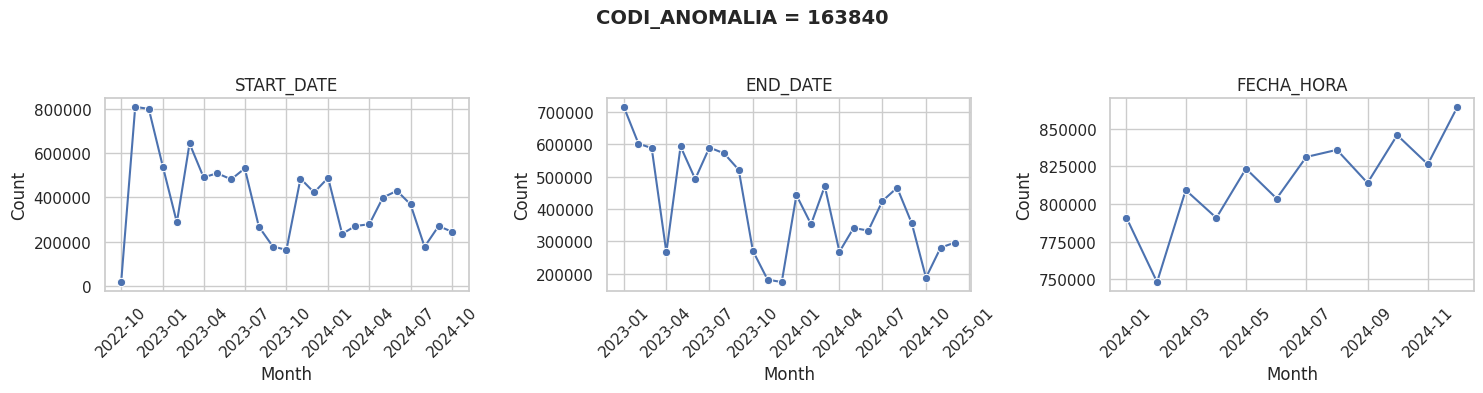

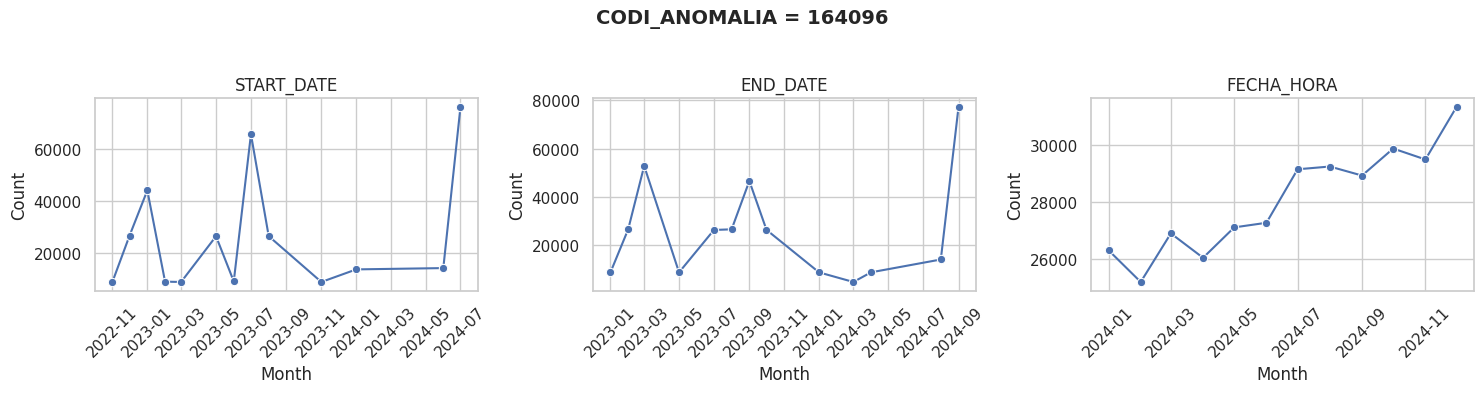

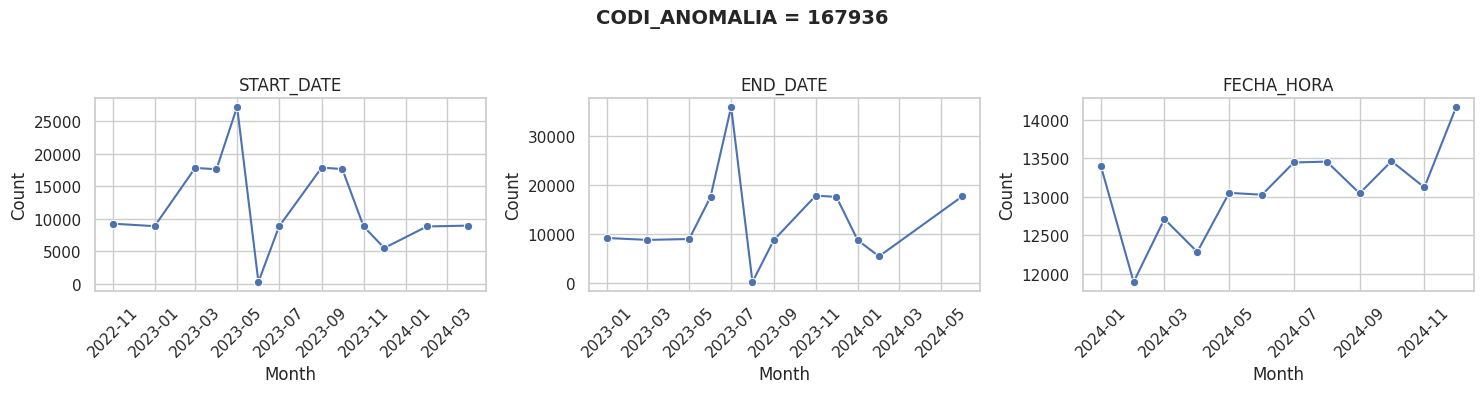

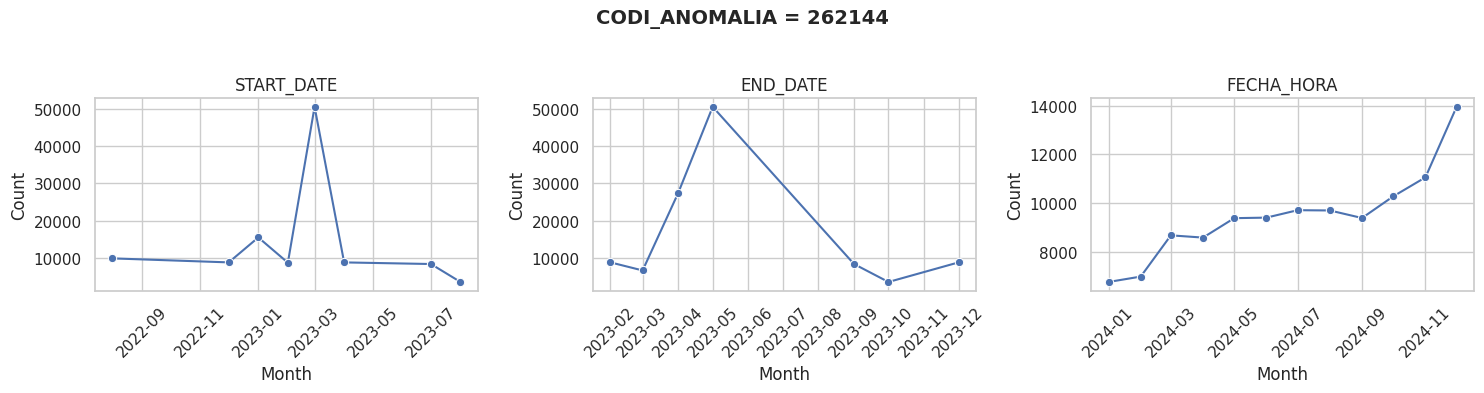

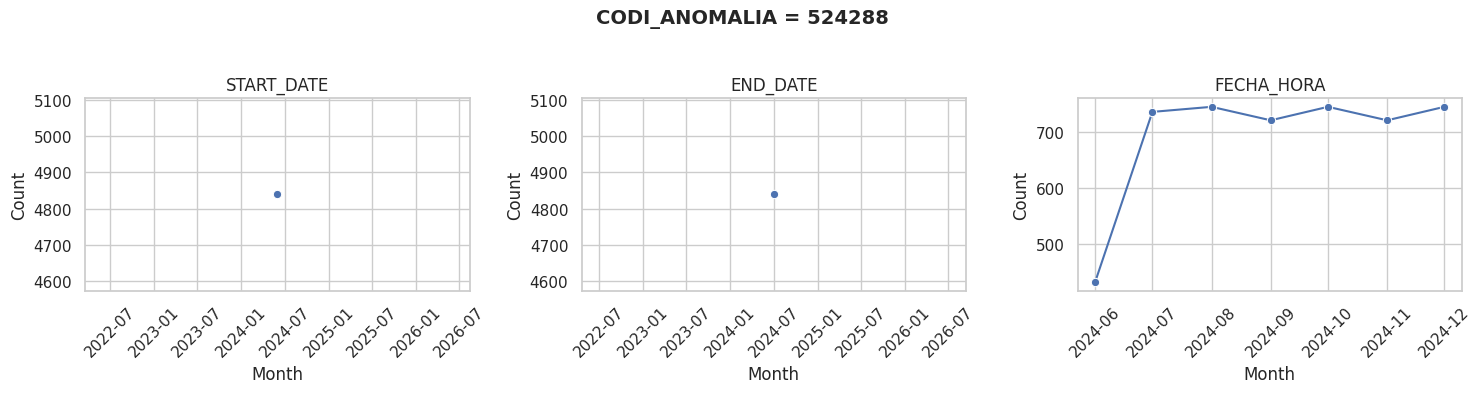

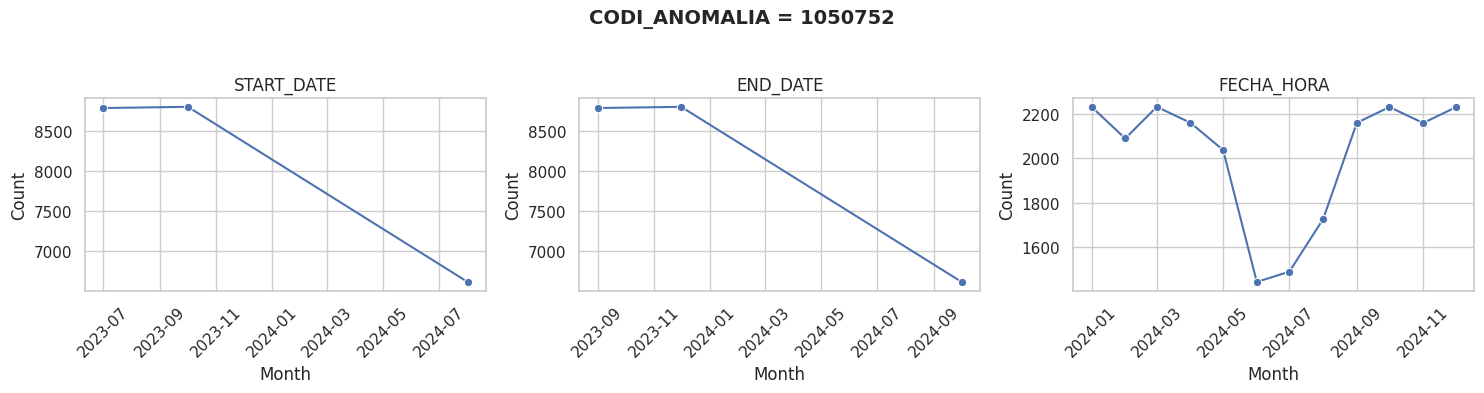

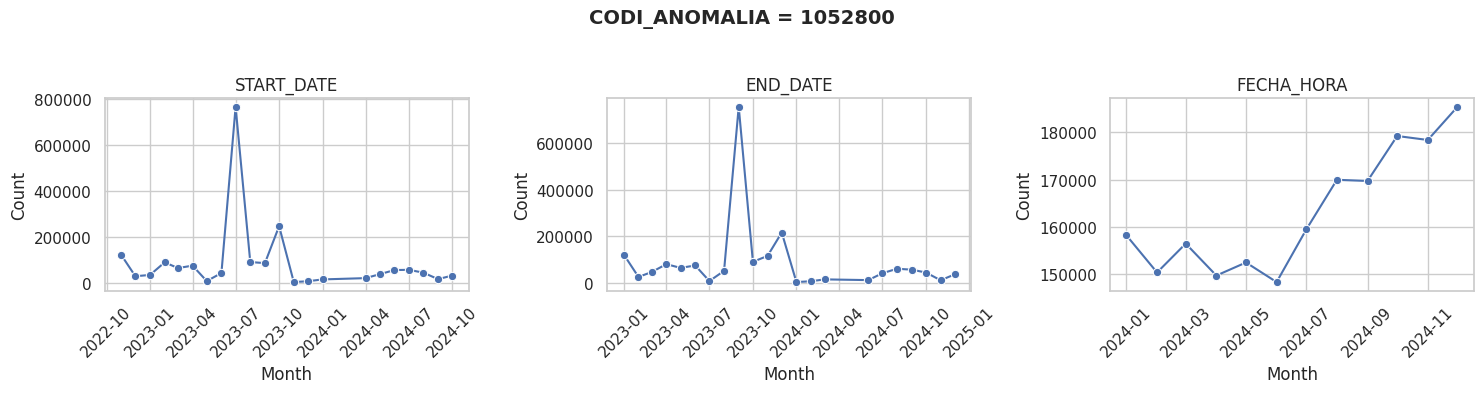

In [ ]:
print("\nGenerating date distribution plots by CODI_ANOMALIA (grouped by anomaly)...")

for anom in anomaly_types:
    subset = df_ab[df_ab[target_col] == anom]

    fig, axes = plt.subplots(1, len(date_cols), figsize=(5 * len(date_cols), 4))
    fig.suptitle(f"CODI_ANOMALIA = {anom}", fontsize=14, fontweight="bold")

    for i, date_col in enumerate(date_cols):
        ax = axes[i]

        # Drop missing and convert to monthly timestamps for readability
        df_temp = (
            subset[[date_col]]
            .dropna()
            .assign(period=subset[date_col].dt.to_period('M').dt.to_timestamp())  # <-- FIX
            .groupby('period')
            .size()
            .reset_index(name='count')
        )

        if len(df_temp) > 0:
            sns.lineplot(
                data=df_temp,
                x='period',
                y='count',
                marker='o',
                ax=ax
            )
            ax.set_title(date_col)
            ax.set_xlabel("Month")
            ax.set_ylabel("Count")
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=12)
            ax.set_axis_off()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

## Conclusion

Data Filtering:
- We will remove rows with date types prior to 2022.
- We will remove the dimesnions POLISSA_SUBM and NUMEROSERIECONTADOR as they are identificators with no relevance to our conclusion.

Handling Null Values:
- SECCIO_CENSAL: we will remove rows with null values in this categor as it is the link with other datasets.
- CONSUMO_REAL: for this numerical features, we will use the median which is robust to outliers. We don't want to remove this rows as the null values account for roughly 20% of the dataset.